# Axion PINN V14 — Extended Domain t ∈ [1e-8, 1]

## Design Overview

Extends V13 from 5 decades (t ∈ [1e-5, 1]) to **7 decades (t ∈ [1e-8, 1])** using a refined 8-stage curriculum.

### Sub-domain normalization
| Parameter | V13 | V14 |
|---|---|---|
| TAU_SPLIT | 0.50 | **0.20** |
| t_split | 1e-5 | **1e-8** |
| sub_log_dt | 11.513 | **18.421** |
| ds/dt @ t_split | 8 686 | **5 430 000** |

### Key insight
Sub-domain normalization `s = (ln t − ln t_split) / sub_log_dt ∈ [0,1]` maps exactly **one decade per 0.125 in s-space**:

| s_min | t_min | ds/dt | Stage |
|---|---|---|---|
| 0.875 | 1e-1 | 0.54 | A |
| 0.750 | 1e-2 | 5.4 | B |
| 0.625 | 1e-3 | 54 | C |
| 0.500 | 1e-4 | 543 | D |
| 0.375 | 1e-5 | 5 430 | E |
| 0.250 | 1e-6 | 54 300 | F |
| 0.125 | 1e-7 | 543 000 | G |
| 0.000 | 1e-8 | 5 430 000 | H |

Stages A–E overlap with V13 (A–E start from 0.875, V13 started from 0.80) giving a warm-start advantage.  
Stages F–H are fully new territory but the field is **completely frozen** (mₐt ≪ 1), making the physics trivial despite large ds/dt.

### Architecture
- Networks: `ScaleFactorNet`, `PhiNet (WKB)`, `DPhiNet (WKB)` — hidden=**128**, depth=5 (wider than V13 to cover 7 decades)
- WKB ICs at t_split=1e-8: mₐ·t_split = 1e-6 rad (deeply frozen, φ ≈ 1, φ̇ ≈ 0)


In [1]:
"""Imports and global config — float64 throughout."""
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)
print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

_LOG_T0 = np.log(PARAMS['t_init'])   # ln(1e-10) = -23.026
_LOG_T1 = np.log(PARAMS['t_end'])    # ln(1.0)   = 0
_LOG_DT = _LOG_T1 - _LOG_T0          # 23.026  (10 decades total)

# ── V14: sub-domain t ∈ [t_split_V14, t_end]  (τ_split = 0.20 → t ≈ 1e-8) ──
# Each 0.125 step in s = exactly 1 decade in t  (8 decades: 1e-8 → 1)
TAU_SPLIT    = 0.20
_LOG_T_SPLIT = _LOG_T0 + TAU_SPLIT * _LOG_DT    # = ln(1e-8) = -18.421
_SUB_LOG_DT  = _LOG_DT * (1.0 - TAU_SPLIT)      # = 0.80 × 23.026 = 18.421
T_SPLIT_NP   = float(np.exp(_LOG_T_SPLIT))       # = 1e-8

def t_to_s(t_tensor):
    """Map physical time t → normalised coordinate s ∈ [0,1]."""
    return (torch.log(torch.clamp(t_tensor, min=EPS)) - _LOG_T_SPLIT) / _SUB_LOG_DT

def s_to_t(s_tensor):
    """Inverse: s → t."""
    return torch.exp(_LOG_T_SPLIT + s_tensor * _SUB_LOG_DT)

print(f"PARAMS defined.")
print(f"t_split (V14) = {T_SPLIT_NP:.3e}  (tau_split={TAU_SPLIT})")
print(f"sub_log_dt    = {_SUB_LOG_DT:.4f}  (= 8 × ln10 exactly)")
print(f"s step per decade = {1.0/8.0:.4f}")
print(f"ds/dt @ t_split (1e-8) = {1.0/(T_SPLIT_NP*_SUB_LOG_DT):.2e}")
print(f"ds/dt @ t=1e-5         = {1.0/(1e-5*_SUB_LOG_DT):.1f}  (V13 boundary)")
print(f"ds/dt @ t=1e-3         = {1.0/(1e-3*_SUB_LOG_DT):.1f}")
print(f"ds/dt @ t=0.10         = {1.0/(0.10*_SUB_LOG_DT):.2f}")


PyTorch 2.7.0+cu126 | device=cuda | dtype=torch.float64
PARAMS defined.
t_split (V14) = 1.000e-08  (tau_split=0.2)
sub_log_dt    = 18.4207  (= 8 × ln10 exactly)
s step per decade = 0.1250
ds/dt @ t_split (1e-8) = 5.43e+06
ds/dt @ t=1e-5         = 5428.7  (V13 boundary)
ds/dt @ t=1e-3         = 54.3
ds/dt @ t=0.10         = 0.54


In [2]:
# ── ODE reference ─────────────────────────────────────────────────────────────
def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s   = max(a, 1e-30)
    rax   = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1    = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2    = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2    = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]

def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    t_eval = np.clip(t_eval, t0, t1)   # guard against float boundary overshoot
    print("Solving ODE reference (RK45)...")
    t0w = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t0w:.2f}s | success={sol.success}")
    if not sol.success:
        warnings.warn(sol.message)
    return sol  # sol.y[0]=a(t), sol.y[1]=phi(t), sol.y[2]=dphi(t)


def physics_residuals(a, phi, dphi, da_dt, d_dphi_dt, ma, rho_m0, rho_r0, rho_L):
    """First-order residuals (no d2phi/dt2 required)."""
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*dphi**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)
    E1    = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1    = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F   = da_dt - H1
    E2    = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2    = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG  = d_dphi_dt + sqrt3*H2*dphi + ma**2*phi
    return R_F, R_KG

print("ODE + physics residuals defined.")


ODE + physics residuals defined.


In [3]:
# ── Architecture ──────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=128, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, s):
        return self.net(s)


class ScaleFactorNet(nn.Module):
    """a(t) = a_split * exp(clamp(s*g(s), max=60)),  a(t_split)=a_split exactly."""
    def __init__(self, a_split, hidden=128, depth=5):
        super().__init__()
        self.register_buffer('log_a_split', torch.tensor(np.log(float(a_split)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def set_g_init(self, g_star):
        for m in reversed(list(self.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, float(g_star))
                break

    def forward(self, s):
        return torch.exp(self.log_a_split + torch.clamp(s * self.net(s), max=60.0))


class PhiNet(nn.Module):
    """WKB ansatz: phi = (A0 + s²·fA(s))·cos(ma·t) + (B0 + s²·fB(s))·sin(ma·t).
    Hard IC at s=0: phi(t_split) = A0·cos(...) + B0·sin(...) exactly."""
    def __init__(self, A0, B0, ma, hidden=128, depth=4):
        super().__init__()
        self.register_buffer('A0', torch.tensor(float(A0), dtype=DTYPE))
        self.register_buffer('B0', torch.tensor(float(B0), dtype=DTYPE))
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_A = FCNN(1, 1, hidden, depth)
        self.net_B = FCNN(1, 1, hidden, depth)

    def forward(self, s, t):
        A = self.A0 + s**2 * self.net_A(s)
        B = self.B0 + s**2 * self.net_B(s)
        return A * torch.cos(self.ma * t) + B * torch.sin(self.ma * t)


class DPhiNet(nn.Module):
    """WKB ansatz: dphi = (C0 + s²·fC(s))·cos(ma·t) + (D0 + s²·fD(s))·sin(ma·t).
    Hard IC at s=0: dphi(t_split) = C0·cos(...) + D0·sin(...) exactly."""
    def __init__(self, C0, D0, ma, hidden=128, depth=4):
        super().__init__()
        self.register_buffer('C0', torch.tensor(float(C0), dtype=DTYPE))
        self.register_buffer('D0', torch.tensor(float(D0), dtype=DTYPE))
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_C = FCNN(1, 1, hidden, depth)
        self.net_D = FCNN(1, 1, hidden, depth)

    def forward(self, s, t):
        C = self.C0 + s**2 * self.net_C(s)
        D = self.D0 + s**2 * self.net_D(s)
        return C * torch.cos(self.ma * t) + D * torch.sin(self.ma * t)


class AxionPINN_V14(nn.Module):
    """Three-network PINN restricted to s ∈ [0,1]  ↔  t ∈ [t_split_V14, t_end]."""
    def __init__(self, a_split, A0, B0, C0, D0, ma,
                 a_hidden=128, a_depth=5,
                 phi_hidden=128, phi_depth=4,
                 dphi_hidden=128, dphi_depth=4):
        super().__init__()
        self.register_buffer('_log_t_split', torch.tensor(_LOG_T_SPLIT, dtype=DTYPE))
        self.register_buffer('_sub_log_dt',  torch.tensor(_SUB_LOG_DT,  dtype=DTYPE))
        self.a_net    = ScaleFactorNet(a_split, a_hidden, a_depth)
        self.phi_net  = PhiNet(A0, B0, ma, phi_hidden, phi_depth)
        self.dphi_net = DPhiNet(C0, D0, ma, dphi_hidden, dphi_depth)

    def _to_s(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t_split) / self._sub_log_dt

    def forward(self, t):
        s    = self._to_s(t)
        a    = self.a_net(s)
        phi  = self.phi_net(s, t)
        dphi = self.dphi_net(s, t)
        return a, phi, dphi


print("Classes defined: FCNN, ScaleFactorNet, PhiNet, DPhiNet, AxionPINN_V14")
n_params_estimate = (128*128*5 + 128*4*2) * 3  # rough estimate
print(f"Approx parameters per network (hidden=128, depth=5): ~{128*5*128 + 128:,}")


Classes defined: FCNN, ScaleFactorNet, PhiNet, DPhiNet, AxionPINN_V14
Approx parameters per network (hidden=128, depth=5): ~82,048


In [4]:
import time as _time_mod

class AxionPINNSolver_V14:
    """
    V14: Extended sub-domain PINN covering t ∈ [t_split_V14=1e-8, t_end=1].

    Key design:
    * t_split_V14 = 1e-8  (tau_split=0.20, sub_log_dt=18.421)
    * s step of 0.125 = exactly 1 decade of physical time
    * WKB hard ICs at t_split from ODE (ma·t_split = 1e-6 rad, deeply frozen)
    * 8-stage curriculum (A→H) extending backward from s=0.875 to s=0.000
    * Stages A–E overlap with V13's proven region
    * Stages F–H (t < 1e-5): field completely frozen, physics trivial
    * Larger network capacity: hidden=128 (vs V13's 64) to cover 7 decades
    * For t < t_split_V14: ODE interpolation
    """

    def __init__(self, n_colloc=2000, hidden=128, depth_a=5, depth_phi=4, seed=42):
        torch.manual_seed(seed)
        np.random.seed(seed)

        # 1. ODE reference (full domain 1e-10 → 1)
        sol = solve_ode(PARAMS)
        self.t_ode    = sol.t
        self.a_ode    = sol.y[0]
        self.phi_ode  = sol.y[1]
        self.dphi_ode = sol.y[2]
        self.T_SPLIT  = float(np.exp(_LOG_T_SPLIT))   # = 1e-8

        # 2. ICs at t_split from ODE
        a_spl    = float(np.interp(self.T_SPLIT, self.t_ode, self.a_ode))
        phi_spl  = float(np.interp(self.T_SPLIT, self.t_ode, self.phi_ode))
        dphi_spl = float(np.interp(self.T_SPLIT, self.t_ode, self.dphi_ode))

        # 3. WKB rotation: exact IC recovery at s=0
        #    phi(t) = A·cos(ma·t) + B·sin(ma·t) → A,B from IC
        #    dphi(t) = C·cos(ma·t) + D·sin(ma·t) with C=ma·B, D=-ma·A (derivative)
        ma   = PARAMS['ma']
        c    = ma * self.T_SPLIT          # ma·t_split = 1e-6 rad (deeply frozen)
        A0   =  phi_spl * np.cos(c) - (dphi_spl / ma) * np.sin(c)
        B0   =  phi_spl * np.sin(c) + (dphi_spl / ma) * np.cos(c)
        C0   =  B0 * ma
        D0   = -A0 * ma
        print(f"t_split_V14 = {self.T_SPLIT:.3e} | ma*t_split = {c:.2e} rad (frozen)")
        print(f"A0={A0:.8f}  B0={B0:.8f}")
        print(f"C0={C0:.4e}  D0={D0:.4e}")
        print(f"IC check phi:  {A0*np.cos(c)+B0*np.sin(c):.10f}  (expect {phi_spl:.10f})")
        print(f"IC check dphi: {C0*np.cos(c)+D0*np.sin(c):.6e}   (expect {dphi_spl:.6e})")

        # 4. ODE-calibrated g_star for a_net (sub-domain t >= T_SPLIT only)
        mask_sub  = self.t_ode >= self.T_SPLIT * 0.9999
        s_sub     = (np.log(self.t_ode[mask_sub]) - _LOG_T_SPLIT) / _SUB_LOG_DT
        log_a_rel = np.log(self.a_ode[mask_sub] / a_spl)
        g_star    = float(np.dot(s_sub, log_a_rel) / np.dot(s_sub, s_sub))
        print(f"g_star (V14 sub-domain) = {g_star:.4f}")

        # 5. Scales (over sub-domain only)
        self.phi_scale  = float(max(np.max(np.abs(self.phi_ode)), 1e-4))
        self.dphi_scale = float(max(np.max(np.abs(self.dphi_ode[mask_sub])), 1e-4))
        print(f"phi_scale={self.phi_scale:.2f}  dphi_scale={self.dphi_scale:.3e}")

        # 6. Reference tensors (sub-domain only, for anchor loss and pretrain)
        t_sub = self.t_ode[mask_sub]
        self.t_ref_torch    = torch.tensor(t_sub[:, None],                     dtype=DTYPE)
        self.la_ref         = torch.tensor(np.log(self.a_ode[mask_sub, None]), dtype=DTYPE)
        self.phi_ref_torch  = torch.tensor(self.phi_ode[mask_sub, None],       dtype=DTYPE)
        self.dphi_ref_torch = torch.tensor(self.dphi_ode[mask_sub, None],      dtype=DTYPE)

        # 7. Build model
        self.model = AxionPINN_V14(
            a_split=a_spl, A0=A0, B0=B0, C0=C0, D0=D0, ma=ma,
            a_hidden=hidden, a_depth=depth_a,
            phi_hidden=hidden, phi_depth=depth_phi,
            dphi_hidden=hidden, dphi_depth=depth_phi,
        )
        self.model.a_net.set_g_init(g_star)
        self.n_colloc = n_colloc
        self.loss_log = []

    # ── collocation with curriculum support ────────────────────────────────────
    def _make_colloc(self, n=None, s_min=0.0):
        """Sample collocation points uniformly in s ∈ [s_min, 1]."""
        if n is None:
            n = self.n_colloc
        s_b = s_min + (1.0 - s_min) * torch.rand(n, 1, dtype=DTYPE)
        return s_to_t(s_b).requires_grad_(True)

    # ── physics loss ──────────────────────────────────────────────────────────
    def _physics_loss(self, t_col):
        p = PARAMS
        a, phi, dphi = self.model(t_col)
        ones      = torch.ones_like(a)
        da_dt     = torch.autograd.grad(a,    t_col, grad_outputs=ones,
                                        create_graph=True, retain_graph=True)[0]
        d_dphi_dt = torch.autograd.grad(dphi, t_col, grad_outputs=ones,
                                        create_graph=True, retain_graph=True)[0]
        d_phi_dt  = torch.autograd.grad(phi,  t_col, grad_outputs=ones,
                                        create_graph=True)[0]
        R_F, R_KG = physics_residuals(
            a, phi, dphi, da_dt, d_dphi_dt,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'])
        R_phi = d_phi_dt - dphi
        with torch.no_grad():
            a_d   = a.detach().clamp(min=EPS)
            rax_d = 0.5*dphi.detach()**2 + 0.5*p['ma']**2*phi.detach()**2
            E1_d  = rax_d + p['rho_m0']/a_d + p['rho_r0']/a_d**2 + p['rho_L']*a_d**2
            H_ref = torch.sqrt(torch.clamp(E1_d/3.0, min=1e-60))
        l_F   = torch.mean((R_F   / (H_ref + EPS))**2)
        l_KG  = torch.mean((R_KG  / (p['ma']**2 * self.phi_scale))**2)
        l_phi = torch.mean((R_phi / (self.dphi_scale + EPS))**2)
        return l_F, l_KG, l_phi

    # ── anchor loss ───────────────────────────────────────────────────────────
    def _anchor_loss(self):
        a_p, phi_p, dphi_p = self.model(self.t_ref_torch)
        la_p = torch.log(torch.clamp(a_p, min=EPS))
        l_a    = torch.mean((la_p   - self.la_ref)**2)
        l_phi  = torch.mean((phi_p  - self.phi_ref_torch)**2)  / self.phi_scale**2
        l_dphi = torch.mean((dphi_p - self.dphi_ref_torch)**2) / self.dphi_scale**2
        return l_a + l_phi + l_dphi

    # ── pretrain on ODE reference ─────────────────────────────────────────────
    def pretrain_a(self, epochs=8000, lr=1e-3, print_every=2000):
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"=== Pretrain a_net ({epochs} ep) ===")
        for ep in range(1, epochs+1):
            opt.zero_grad()
            s_v  = self.model._to_s(self.t_ref_torch)
            a_p  = self.model.a_net(s_v)
            loss = torch.mean((torch.log(torch.clamp(a_p, min=EPS)) - self.la_ref)**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss={loss.item():.3e}")
        with torch.no_grad():
            s_v = self.model._to_s(self.t_ref_torch)
            re  = (torch.exp(self.la_ref) - self.model.a_net(s_v)).abs() / \
                  torch.exp(self.la_ref).abs()
        print(f"  Done -- median {re.median().item():.3e}  max {re.max().item():.3e}")

    def pretrain_phi(self, epochs=5000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"=== Pretrain phi_net ({epochs} ep, WKB) ===")
        for ep in range(1, epochs+1):
            opt.zero_grad()
            s_v   = self.model._to_s(self.t_ref_torch)
            phi_p = self.model.phi_net(s_v, self.t_ref_torch)
            loss  = torch.mean((phi_p - self.phi_ref_torch)**2) / self.phi_scale**2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.phi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss={loss.item():.3e}")
        with torch.no_grad():
            s_v = self.model._to_s(self.t_ref_torch)
            re  = (self.phi_ref_torch - self.model.phi_net(s_v, self.t_ref_torch)).abs() / \
                  (self.phi_ref_torch.abs() + 1e-30)
        print(f"  Done -- median {re.median().item():.3e}  max {re.max().item():.3e}")

    def pretrain_dphi(self, epochs=5000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.dphi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"=== Pretrain dphi_net ({epochs} ep, WKB) ===")
        for ep in range(1, epochs+1):
            opt.zero_grad()
            s_v    = self.model._to_s(self.t_ref_torch)
            dphi_p = self.model.dphi_net(s_v, self.t_ref_torch)
            loss   = torch.mean((dphi_p - self.dphi_ref_torch)**2) / self.dphi_scale**2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.dphi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss={loss.item():.3e}")
        with torch.no_grad():
            s_v = self.model._to_s(self.t_ref_torch)
            re  = (self.dphi_ref_torch - self.model.dphi_net(s_v, self.t_ref_torch)).abs() / \
                  (self.dphi_ref_torch.abs() + 1e-30)
        print(f"  Done -- median {re.median().item():.3e}  max {re.max().item():.3e}")

    # ── Adam curriculum stage ─────────────────────────────────────────────────
    def _train_stage(self, label, epochs, lr, s_min,
                     lam_kg=10.0, lam_phi=0.1, lam_anc=0.1, print_every=None):
        opt   = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-6)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        if print_every is None:
            print_every = max(1, epochs // 20)
        t_min_phys   = float(s_to_t(torch.tensor([[s_min]])).item())
        dsdt_at_smin = 1.0 / (t_min_phys * _SUB_LOG_DT) if t_min_phys > 0 else float('inf')
        print(f"\n=== {label}  (s>={s_min:.3f}, t>={t_min_phys:.1e}, "
              f"ds/dt_left={dsdt_at_smin:.2e}, {epochs} ep, lr={lr:.1e}) ===")
        t0 = _time_mod.time()
        for ep in range(1, epochs+1):
            opt.zero_grad()
            t_col = self._make_colloc(s_min=s_min)
            l_F, l_KG, l_phi = self._physics_loss(t_col)
            l_anc = self._anchor_loss()
            loss  = l_F + lam_kg*l_KG + lam_phi*l_phi + lam_anc*l_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            opt.step(); sched.step()
            self.loss_log.append({
                'ep': ep, 'label': label, 's_min': s_min,
                'F': l_F.item(), 'KG': l_KG.item(),
                'phi_cons': l_phi.item(), 'anc': l_anc.item(),
                'total': loss.item()
            })
            if ep % print_every == 0:
                print(f"  ep {ep:5d}/{epochs}  F={l_F.item():.2e}  "
                      f"KG={l_KG.item():.2e}  phi_cons={l_phi.item():.2e}  "
                      f"anc={l_anc.item():.2e}  t={_time_mod.time()-t0:.0f}s")

    # ── L-BFGS polish ──────────────────────────────────────────────────────────
    def lbfgs_polish(self, max_iter=500, s_min=0.0,
                     lam_kg=10.0, lam_phi=1.0, lam_anc=0.1):
        print(f"\n=== L-BFGS Polish ({max_iter} iter, s>={s_min:.3f}) ===")
        opt   = torch.optim.LBFGS(self.model.parameters(), max_iter=max_iter,
                                   tolerance_grad=1e-9, history_size=50,
                                   line_search_fn='strong_wolfe')
        t_col = self._make_colloc(n=4000, s_min=s_min)
        _last = {}
        def closure():
            opt.zero_grad()
            l_F, l_KG, l_phi = self._physics_loss(t_col)
            l_anc = self._anchor_loss()
            loss  = l_F + lam_kg*l_KG + lam_phi*l_phi + lam_anc*l_anc
            loss.backward()
            _last.update({'F': l_F.item(), 'KG': l_KG.item(),
                          'phi': l_phi.item(), 'anc': l_anc.item()})
            return loss
        opt.step(closure)
        print(f"  Final: F={_last.get('F',float('nan')):.2e}  "
              f"KG={_last.get('KG',float('nan')):.2e}  "
              f"phi_cons={_last.get('phi',float('nan')):.2e}  "
              f"anc={_last.get('anc',float('nan')):.2e}")

    # ── Full 8-stage curriculum ────────────────────────────────────────────────
    def train_all(self):
        t_wall = _time_mod.time()
        print("=" * 70)
        print("V14 Training  --  t ∈ [1e-8, 1]  (8-stage curriculum, hidden=128)")
        print("=" * 70)
        print("Stage summary (s step=0.125 = 1 decade per stage):")
        for s_min, t_min, dsdt in [
            (0.875,'1e-1',0.54), (0.750,'1e-2',5.4), (0.625,'1e-3',54),
            (0.500,'1e-4',543),  (0.375,'1e-5',5430),(0.250,'1e-6',54300),
            (0.125,'1e-7',543000),(0.000,'1e-8',5430000)]:
            print(f"  s>={s_min:.3f}  t>={t_min}  ds/dt~{dsdt:.2e}")

        # Pre-training on ODE reference
        print("\n[1/9] Pre-training (ODE supervised)")
        self.pretrain_a(epochs=8000,  lr=1e-3, print_every=2000)
        self.pretrain_phi(epochs=5000,  lr=1e-3, print_every=1000)
        self.pretrain_dphi(epochs=5000, lr=1e-3, print_every=1000)

        # Stage A: s >= 0.875  (t >= 0.10, late-time oscillations)
        self._train_stage("Stage A (s>=0.875, t>=1e-1)", epochs=4000, lr=5e-4,
                          s_min=0.875, lam_kg=10.0, lam_phi=0.1, lam_anc=0.5)

        # Stage B: s >= 0.750  (t >= 0.01, field oscillating rapidly)
        self._train_stage("Stage B (s>=0.750, t>=1e-2)", epochs=5000, lr=3e-4,
                          s_min=0.750, lam_kg=10.0, lam_phi=0.1, lam_anc=0.3)

        # Stage C: s >= 0.625  (t >= 1e-3, oscillation onset)
        self._train_stage("Stage C (s>=0.625, t>=1e-3)", epochs=6000, lr=2e-4,
                          s_min=0.625, lam_kg=10.0, lam_phi=0.1, lam_anc=0.2)

        # Stage D: s >= 0.500  (t >= 1e-4)
        self._train_stage("Stage D (s>=0.500, t>=1e-4)", epochs=7000, lr=1e-4,
                          s_min=0.500, lam_kg=10.0, lam_phi=0.1, lam_anc=0.2)

        # Stage E: s >= 0.375  (t >= 1e-5, V13 split boundary)
        self._train_stage("Stage E (s>=0.375, t>=1e-5)", epochs=8000, lr=1e-4,
                          s_min=0.375, lam_kg=10.0, lam_phi=0.1, lam_anc=0.2)

        # Stage F: s >= 0.250  (t >= 1e-6, new V14 territory)
        self._train_stage("Stage F (s>=0.250, t>=1e-6)", epochs=8000, lr=5e-5,
                          s_min=0.250, lam_kg=10.0, lam_phi=0.1, lam_anc=0.15)

        # Stage G: s >= 0.125  (t >= 1e-7, deeply frozen)
        self._train_stage("Stage G (s>=0.125, t>=1e-7)", epochs=10000, lr=3e-5,
                          s_min=0.125, lam_kg=10.0, lam_phi=0.1, lam_anc=0.1)

        # Stage H: s >= 0.000  (t >= 1e-8, full V14 domain)
        self._train_stage("Stage H (s>=0.000, t>=1e-8)", epochs=12000, lr=1e-5,
                          s_min=0.000, lam_kg=10.0, lam_phi=0.1, lam_anc=0.1)

        # L-BFGS polish on full V14 domain
        self.lbfgs_polish(max_iter=500, s_min=0.000)

        total_min = (_time_mod.time() - t_wall) / 60.0
        print(f"\nTotal wall time: {total_min:.1f} min")

    # ── Hybrid evaluation ─────────────────────────────────────────────────────
    def evaluate(self, n_eval=1000):
        """Hybrid: ODE for t < t_split_V14, PINN for t >= t_split_V14."""
        t_eval    = np.logspace(np.log10(PARAMS['t_init']),
                                np.log10(PARAMS['t_end']), n_eval)
        t_eval    = np.clip(t_eval, PARAMS['t_init'], PARAMS['t_end'])  # guard float boundary
        a_pred    = np.empty_like(t_eval)
        phi_pred  = np.empty_like(t_eval)
        dphi_pred = np.empty_like(t_eval)
        mask_ode  = t_eval <  self.T_SPLIT
        mask_pinn = t_eval >= self.T_SPLIT
        if mask_ode.any():
            a_pred[mask_ode]    = np.interp(t_eval[mask_ode], self.t_ode, self.a_ode)
            phi_pred[mask_ode]  = np.interp(t_eval[mask_ode], self.t_ode, self.phi_ode)
            dphi_pred[mask_ode] = np.interp(t_eval[mask_ode], self.t_ode, self.dphi_ode)
        if mask_pinn.any():
            t_ptorch = torch.tensor(t_eval[mask_pinn, None], dtype=DTYPE)
            with torch.no_grad():
                ap, pp, dp = self.model(t_ptorch)
            a_pred[mask_pinn]    = ap.numpy().ravel()
            phi_pred[mask_pinn]  = pp.numpy().ravel()
            dphi_pred[mask_pinn] = dp.numpy().ravel()
        return t_eval, a_pred, phi_pred, dphi_pred


print("AxionPINNSolver_V14 defined.")
print(f"Total expected Adam epochs: {8000+5000+5000+4000+5000+6000+7000+8000+8000+10000+12000:,} + L-BFGS 500")


AxionPINNSolver_V14 defined.
Total expected Adam epochs: 78,000 + L-BFGS 500


In [5]:
def plot_comparison_v14(solver, save_dir='results_v14'):
    os.makedirs(save_dir, exist_ok=True)
    t_eval, a_pred, phi_pred, dphi_pred = solver.evaluate()
    t_ode, a_ode, phi_ode, dphi_ode = solver.t_ode, solver.a_ode, solver.phi_ode, solver.dphi_ode
    T_SPLIT = solver.T_SPLIT
    mask_pinn = t_eval >= T_SPLIT

    a_ref    = np.interp(t_eval, t_ode, a_ode)
    phi_ref  = np.interp(t_eval, t_ode, phi_ode)
    dphi_ref = np.interp(t_eval, t_ode, dphi_ode)
    rel_a    = np.abs(a_pred    - a_ref)    / (np.abs(a_ref)    + 1e-30)
    rel_phi  = np.abs(phi_pred  - phi_ref)  / (np.abs(phi_ref)  + 1e-30)
    rel_dphi = np.abs(dphi_pred - dphi_ref) / (np.abs(dphi_ref) + 1e-6)

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(f"PINN V14 vs ODE  |  PINN region: t >= {T_SPLIT:.0e}  (7 decades)", fontsize=12)

    for ax, yt, yp, lab in zip(
            [axes[0,0], axes[1,0], axes[2,0]],
            [a_ode, phi_ode, dphi_ode],
            [a_pred, phi_pred, dphi_pred],
            ['a(t)', 'phi(t)', 'dphi(t)']):
        ax.semilogx(t_ode, yt, 'k-', lw=1.5, label='ODE')
        ax.semilogx(t_eval[mask_pinn], yp[mask_pinn], 'r--', lw=1.5, label='PINN V14')
        ax.axvline(T_SPLIT, color='blue',  lw=0.8, ls=':', label=f't_split={T_SPLIT:.0e}')
        ax.axvline(1e-5,    color='green', lw=0.8, ls=':', label='V13 boundary (1e-5)')
        ax.set_xlabel('t'); ax.set_ylabel(lab)
        ax.set_title(lab); ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.2)

    for ax, rel, lab in zip(
            [axes[0,1], axes[1,1], axes[2,1]],
            [rel_a, rel_phi, rel_dphi],
            ['|da|/a', '|dphi|/|phi|', '|ddphi|/|dphi|']):
        ax.loglog(t_eval[mask_pinn], rel[mask_pinn] + 1e-16, 'r-', lw=1.2)
        ax.axhline(1e-2, color='orange', ls='--', lw=0.8, label='1%')
        ax.axhline(1e-4, color='green',  ls='--', lw=0.8, label='0.01%')
        ax.set_xlabel('t'); ax.set_ylabel(lab); ax.set_title(f'Relative error {lab}')
        ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    plt.tight_layout()
    path = os.path.join(save_dir, 'v14_comparison.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

    with np.errstate(invalid='ignore'):
        print(f"\nPINN region (t >= {T_SPLIT:.0e}) summary:")
        print(f"  a(t)   median={np.median(rel_a[mask_pinn]):.2e}  90th={np.percentile(rel_a[mask_pinn],90):.2e}")
        phi_fin = rel_phi[mask_pinn][np.isfinite(rel_phi[mask_pinn])]
        print(f"  phi(t) 90th  ={np.percentile(phi_fin,90):.2e}")
        dphi_fin = rel_dphi[mask_pinn][np.isfinite(rel_dphi[mask_pinn])]
        print(f"  dphi   90th  ={np.percentile(dphi_fin,90):.2e}")


def plot_loss_v14(solver, save_dir='results_v14'):
    os.makedirs(save_dir, exist_ok=True)
    if not solver.loss_log:
        print("No loss history."); return
    fig, ax = plt.subplots(figsize=(16, 5))
    ep_all   = [d['ep']       for d in solver.loss_log]
    F_all    = [d['F']        for d in solver.loss_log]
    KG_all   = [d['KG']       for d in solver.loss_log]
    phi_all  = [d['phi_cons'] for d in solver.loss_log]
    ax.semilogy(ep_all, np.array(F_all)   + 1e-20, label='Friedmann', lw=1, alpha=0.8)
    ax.semilogy(ep_all, np.array(KG_all)  + 1e-20, label='KG',        lw=1, alpha=0.8)
    ax.semilogy(ep_all, np.array(phi_all) + 1e-20, label='phi_cons',  lw=1, alpha=0.8)
    ax.set_xlabel('Epoch (per stage)'); ax.set_ylabel('Loss')
    ax.set_title('V14 Loss History (8-stage curriculum, t=[1e-8,1])'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(save_dir, 'v14_loss.png')
    plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Saved: {path}")


def region_summary_v14(solver):
    """Per-decade accuracy table comparing V13-covered vs V14-new regions."""
    t_eval, a_pred, phi_pred, _ = solver.evaluate(n_eval=2000)
    t_ode, a_ode, phi_ode = solver.t_ode, solver.a_ode, solver.phi_ode
    a_ref   = np.interp(t_eval, t_ode, a_ode)
    phi_ref = np.interp(t_eval, t_ode, phi_ode)
    rel_a   = np.abs(a_pred   - a_ref)   / (np.abs(a_ref)   + 1e-30)
    rel_phi = np.abs(phi_pred - phi_ref) / (np.abs(phi_ref) + 1e-30)

    decades = [(1e-8, 1e-7, 'V14-new [1e-8, 1e-7]'),
               (1e-7, 1e-6, 'V14-new [1e-7, 1e-6]'),
               (1e-6, 1e-5, 'V14-new [1e-6, 1e-5]'),
               (1e-5, 1e-4, 'V13:    [1e-5, 1e-4]'),
               (1e-4, 1e-3, 'V13:    [1e-4, 1e-3]'),
               (1e-3, 1e-2, 'V13:    [1e-3, 1e-2]'),
               (1e-2, 1e-1, '        [1e-2, 1e-1]'),
               (1e-1, 1.0,  '        [1e-1, 1.0 ]')]
    print("\n┌──────────────────────────────┬─────────────┬─────────────┐")
    print("│ Region                       │  a(t) 90th% │ phi(t) 90th%│")
    print("├──────────────────────────────┼─────────────┼─────────────┤")
    for t_lo, t_hi, label in decades:
        mask = (t_eval >= t_lo) & (t_eval < t_hi) & (t_eval >= solver.T_SPLIT)
        if mask.sum() < 3:
            print(f"│ {label:<28}  │     ---     │     ---     │")
            continue
        a90   = np.percentile(rel_a[mask], 90)
        phi90 = np.percentile(rel_phi[mask][np.isfinite(rel_phi[mask])], 90) \
                if np.isfinite(rel_phi[mask]).any() else float('nan')
        print(f"│ {label:<28}  │  {a90:.2e}   │  {phi90:.2e}   │")
    print("└──────────────────────────────┴─────────────┴─────────────┘")


print("Plotting utilities (V14) defined.")


Plotting utilities (V14) defined.


In [6]:
# ── SMOKE TEST ──────────────────────────────────────────────────────────────
print("=" * 65)
print("SMOKE TEST — V14  (t_split=1e-8, sub_log_dt=18.421, hidden=128)")
print("=" * 65)

torch.manual_seed(42)
solver_v14 = AxionPINNSolver_V14(n_colloc=2000, hidden=128, seed=42)

# Untrained full-domain losses
t_full = solver_v14._make_colloc(n=4000, s_min=0.0)
lF, lKG, lP = solver_v14._physics_loss(t_full)
lA = solver_v14._anchor_loss()
print(f"\nUntrained losses (full s in [0,1], t in [1e-8, 1]):")
print(f"  Friedmann  = {lF:.3e}")
print(f"  KG         = {lKG:.3e}")
print(f"  phi_cons   = {lP:.3e}   (WKB IC → expect < 0.10)")
print(f"  Anchor     = {lA:.3e}")

# Per-stage losses
print("\nPer-curriculum-stage (untrained):")
stages = [(0.875,'A t>=0.1'), (0.750,'B t>=1e-2'), (0.625,'C t>=1e-3'),
          (0.500,'D t>=1e-4'), (0.375,'E t>=1e-5'), (0.250,'F t>=1e-6'),
          (0.125,'G t>=1e-7'), (0.000,'H t>=1e-8')]
for s_min, label in stages:
    t_c = solver_v14._make_colloc(n=800, s_min=s_min)
    lF2, lKG2, lP2 = solver_v14._physics_loss(t_c)
    t_min_np = float(s_to_t(torch.tensor([[s_min]], dtype=DTYPE)))
    ds_dt    = 1.0 / (t_min_np * solver_v14.model._sub_log_dt.item())
    print(f"  Stage {label}:  F={lF2:.2e}  KG={lKG2:.2e}  phi_cons={lP2:.2e}  ds/dt={ds_dt:.2e}")

# Forward pass check
t_check = torch.tensor([[1e-5]], dtype=DTYPE)
a_out, phi_out, dphi_out = solver_v14.model(t_check)
print(f"\nForward pass at t=1e-5: a={float(a_out):.6f}, phi={float(phi_out):.6f}, dphi={float(dphi_out):.4e}")
t_check2 = torch.tensor([[solver_v14.T_SPLIT]], dtype=DTYPE)
a_out2, phi_out2, dphi_out2 = solver_v14.model(t_check2)
print(f"Forward pass at t_split=1e-8: a={float(a_out2):.2e}, phi={float(phi_out2):.8f}, dphi={float(dphi_out2):.4e}")
nan_check = any(np.isnan(v) for v in [float(a_out), float(phi_out), float(dphi_out),
                                       float(a_out2), float(phi_out2), float(dphi_out2)])
print("Smoke test PASSED ✓" if not nan_check else "FAILED — NaN detected!")


SMOKE TEST — V14  (t_split=1e-8, sub_log_dt=18.421, hidden=128)
Solving ODE reference (RK45)...
  Done 0.27s | success=True
t_split_V14 = 1.000e-08 | ma*t_split = 1.00e-06 rad (frozen)
A0=1.00000000  B0=0.00000047
C0=4.7063e-05  D0=-1.0000e+02
IC check phi:  1.0000000000  (expect 1.0000000000)
IC check dphi: -5.293732e-05   (expect -5.293732e-05)
g_star (V14 sub-domain) = 12.8650
phi_scale=1.00  dphi_scale=6.641e+01

Untrained losses (full s in [0,1], t in [1e-8, 1]):
  Friedmann  = 2.550e+00
  KG         = 1.166e-01
  phi_cons   = 3.431e+01   (WKB IC → expect < 0.10)
  Anchor     = 5.883e-01

Per-curriculum-stage (untrained):
  Stage A t>=0.1:  F=7.27e-01  KG=3.13e-01  phi_cons=1.00e-02  ds/dt=5.43e-01
  Stage B t>=1e-2:  F=6.18e-01  KG=3.23e-01  phi_cons=7.34e-03  ds/dt=5.43e+00
  Stage C t>=1e-3:  F=4.76e-01  KG=2.38e-01  phi_cons=6.64e-03  ds/dt=5.43e+01
  Stage D t>=1e-4:  F=3.74e-01  KG=1.89e-01  phi_cons=1.13e-02  ds/dt=5.43e+02
  Stage E t>=1e-5:  F=6.05e-01  KG=1.46e-01  phi_c

In [7]:
# ── TRAINING ────────────────────────────────────────────────────────────────
import os

RESULTS_DIR_V14 = os.path.join(os.getcwd(), 'results_v14')
os.makedirs(RESULTS_DIR_V14, exist_ok=True)

print("Starting V14 training — 8-stage curriculum (t_split=1e-8, hidden=128)")
print(f"Expected total: ~78,000 Adam epochs + L-BFGS 500 steps")
print("-" * 65)

t_start_train = _time_mod.time()
solver_v14.train_all()
t_elapsed = _time_mod.time() - t_start_train

CKPT_PATH_V14 = os.path.join(RESULTS_DIR_V14, 'v14_model.pt')
torch.save({
    'model_state': solver_v14.model.state_dict(),
    'loss_log':    solver_v14.loss_log,
    'T_SPLIT':     solver_v14.T_SPLIT,
    'params':      PARAMS,
}, CKPT_PATH_V14)

print(f"\nTraining complete in {t_elapsed/60:.1f} min")
print(f"Checkpoint saved → {CKPT_PATH_V14}")
if solver_v14.loss_log:
    last = solver_v14.loss_log[-1]
    print(f"Final losses (last record):  F={last['F']:.2e}  KG={last['KG']:.2e}  phi_cons={last['phi_cons']:.2e}")


Starting V14 training — 8-stage curriculum (t_split=1e-8, hidden=128)
Expected total: ~78,000 Adam epochs + L-BFGS 500 steps
-----------------------------------------------------------------
V14 Training  --  t ∈ [1e-8, 1]  (8-stage curriculum, hidden=128)
Stage summary (s step=0.125 = 1 decade per stage):
  s>=0.875  t>=1e-1  ds/dt~5.40e-01
  s>=0.750  t>=1e-2  ds/dt~5.40e+00
  s>=0.625  t>=1e-3  ds/dt~5.40e+01
  s>=0.500  t>=1e-4  ds/dt~5.43e+02
  s>=0.375  t>=1e-5  ds/dt~5.43e+03
  s>=0.250  t>=1e-6  ds/dt~5.43e+04
  s>=0.125  t>=1e-7  ds/dt~5.43e+05
  s>=0.000  t>=1e-8  ds/dt~5.43e+06

[1/9] Pre-training (ODE supervised)
=== Pretrain a_net (8000 ep) ===
  ep  2000 | loss=8.921e-05
  ep  4000 | loss=2.936e-05
  ep  6000 | loss=1.744e-05
  ep  8000 | loss=1.583e-05
  Done -- median 6.474e-04  max 3.652e-02
=== Pretrain phi_net (5000 ep, WKB) ===
  ep  1000 | loss=1.018e-03
  ep  2000 | loss=6.069e-06
  ep  3000 | loss=3.932e-06
  ep  4000 | loss=3.258e-06
  ep  5000 | loss=3.110e-06


  ep  6650/7000  F=5.40e-05  KG=2.10e-06  phi_cons=5.50e-05  anc=3.84e-04  t=1261s
  ep  7000/7000  F=5.23e-05  KG=2.04e-06  phi_cons=5.20e-05  anc=3.84e-04  t=1321s

=== Stage E (s>=0.375, t>=1e-5)  (s>=0.375, t>=1.0e-05, ds/dt_left=5.43e+03, 8000 ep, lr=1.0e-04) ===
  ep   400/8000  F=4.91e-05  KG=2.93e-06  phi_cons=6.71e-05  anc=3.75e-04  t=69s
  ep   800/8000  F=5.26e-05  KG=2.05e-06  phi_cons=4.60e-05  anc=3.76e-04  t=138s
  ep  1200/8000  F=5.05e-05  KG=2.57e-06  phi_cons=3.85e-05  anc=3.67e-04  t=207s
  ep  1600/8000  F=5.11e-05  KG=1.90e-06  phi_cons=4.32e-05  anc=3.65e-04  t=276s
  ep  2000/8000  F=4.09e-05  KG=2.07e-06  phi_cons=4.23e-05  anc=3.59e-04  t=345s
  ep  2400/8000  F=5.06e-05  KG=2.46e-06  phi_cons=5.20e-05  anc=3.56e-04  t=414s
  ep  2800/8000  F=3.47e-05  KG=1.94e-06  phi_cons=5.24e-05  anc=3.57e-04  t=482s
  ep  3200/8000  F=4.16e-05  KG=1.65e-06  phi_cons=4.37e-05  anc=3.50e-04  t=550s
  ep  3600/8000  F=4.74e-05  KG=3.90e-06  phi_cons=9.17e-05  anc=3.52e-04  t

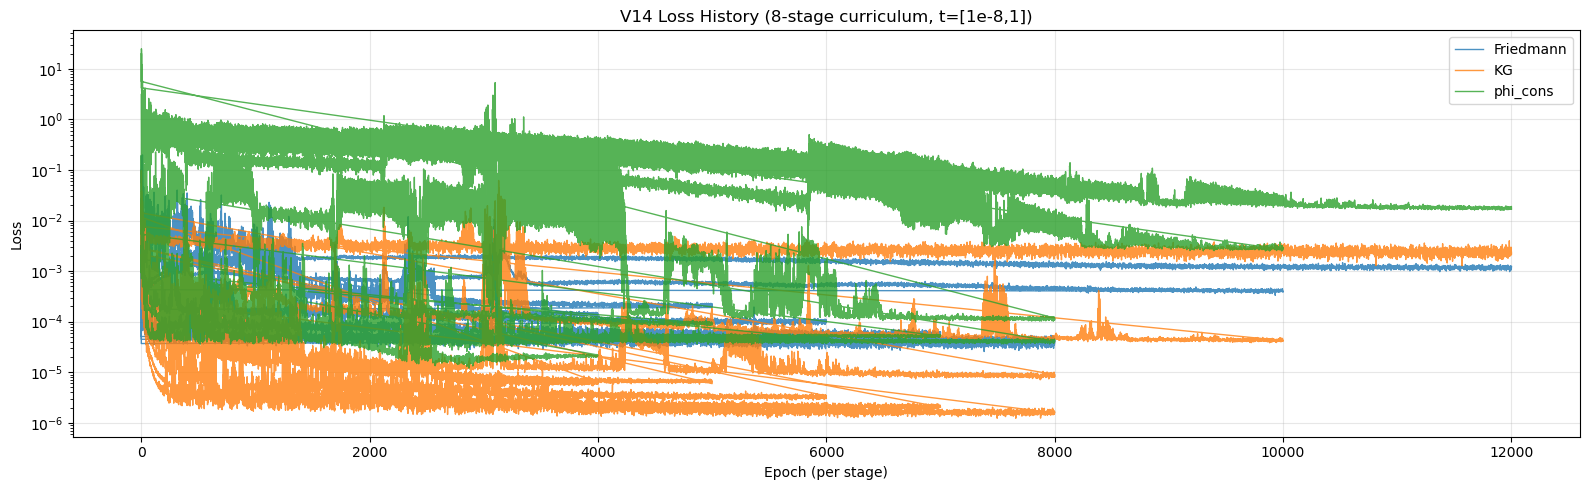

Saved: /home/weerachai/Desktop/Python/New_ver_PINNs_axion/PINNs_axion/results_v14/v14_loss.png


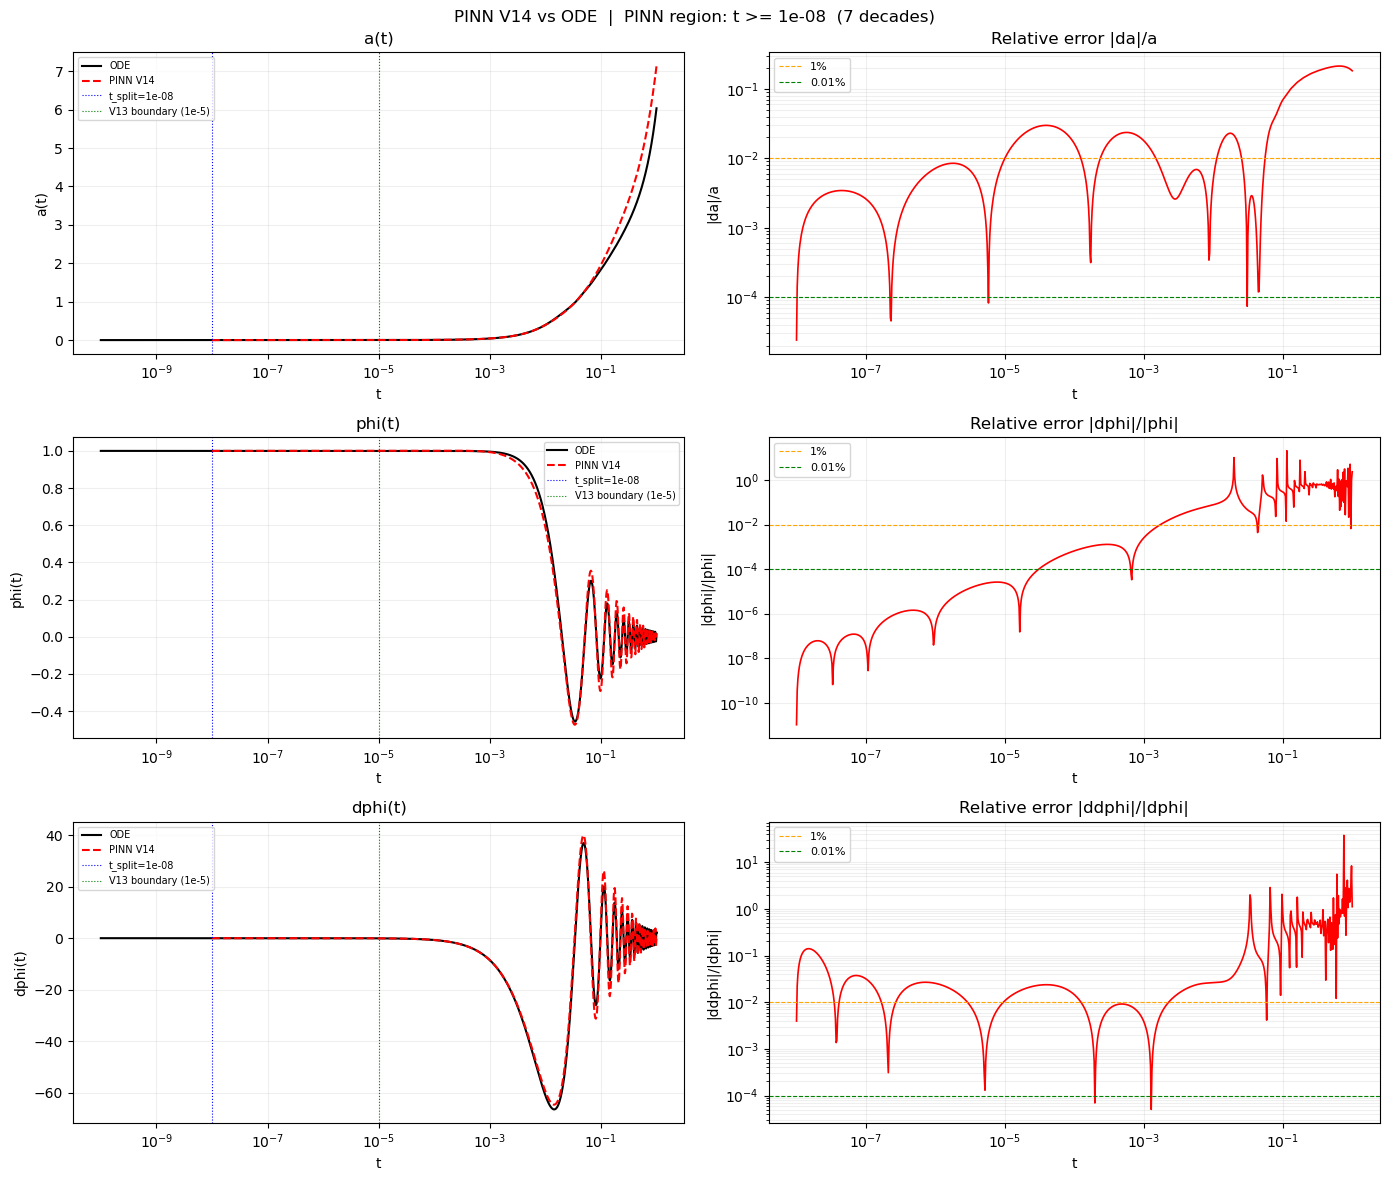

Saved: /home/weerachai/Desktop/Python/New_ver_PINNs_axion/PINNs_axion/results_v14/v14_comparison.png

PINN region (t >= 1e-08) summary:
  a(t)   median=7.92e-03  90th=1.22e-01
  phi(t) 90th  =4.46e-01
  dphi   90th  =3.80e-01

┌──────────────────────────────┬─────────────┬─────────────┐
│ Region                       │  a(t) 90th% │ phi(t) 90th%│
├──────────────────────────────┼─────────────┼─────────────┤
│ V14-new [1e-8, 1e-7]          │  3.42e-03   │  1.14e-07   │
│ V14-new [1e-7, 1e-6]          │  6.13e-03   │  1.40e-06   │
│ V14-new [1e-6, 1e-5]          │  8.45e-03   │  2.58e-05   │
│ V13:    [1e-5, 1e-4]          │  2.96e-02   │  5.04e-04   │
│ V13:    [1e-4, 1e-3]          │  2.33e-02   │  1.28e-03   │
│ V13:    [1e-3, 1e-2]          │  1.33e-02   │  6.40e-02   │
│         [1e-2, 1e-1]          │  4.14e-02   │  4.84e-01   │
│         [1e-1, 1.0 ]          │  2.12e-01   │  9.37e-01   │
└──────────────────────────────┴─────────────┴─────────────┘


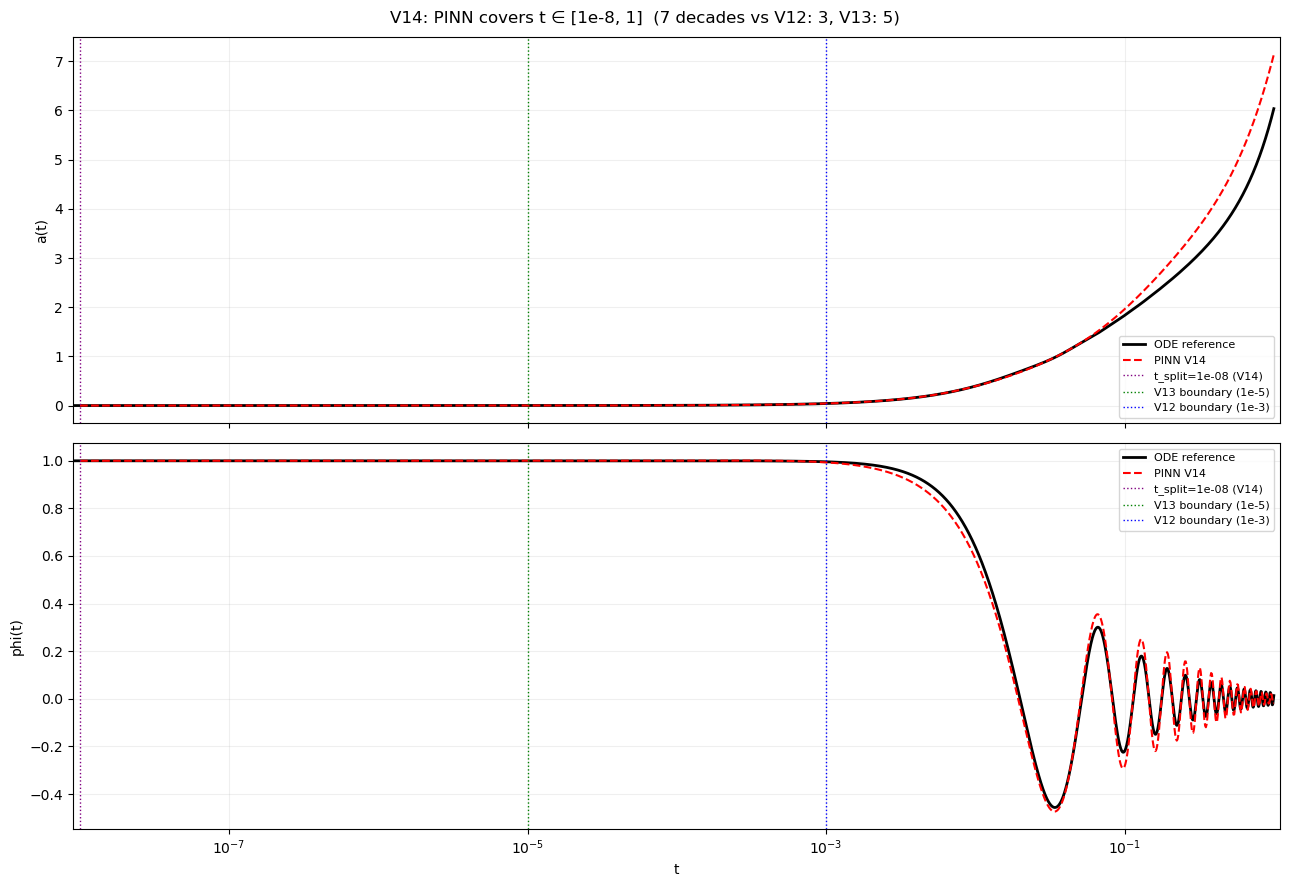

Saved: /home/weerachai/Desktop/Python/New_ver_PINNs_axion/PINNs_axion/results_v14/v14_full_domain.png


In [8]:
# ── EVALUATION & PLOTS ──────────────────────────────────────────────────────
plot_loss_v14(solver_v14, save_dir=RESULTS_DIR_V14)
plot_comparison_v14(solver_v14, save_dir=RESULTS_DIR_V14)
region_summary_v14(solver_v14)

# ── Full domain overview plot ────────────────────────────────────────────────
t_eval, a_pred, phi_pred, _ = solver_v14.evaluate(n_eval=2000)
t_ode, a_ode, phi_ode = solver_v14.t_ode, solver_v14.a_ode, solver_v14.phi_ode

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for ax, yp, yo, lab in zip(axes, [a_pred, phi_pred], [a_ode, phi_ode], ['a(t)', 'phi(t)']):
    ax.semilogx(t_ode, yo, 'k-', lw=2, label='ODE reference')
    mask_all = t_eval >= solver_v14.T_SPLIT
    ax.semilogx(t_eval[mask_all], yp[mask_all], 'r--', lw=1.5, label='PINN V14')
    ax.axvline(solver_v14.T_SPLIT, color='purple', ls=':', lw=1.0, label=f't_split={solver_v14.T_SPLIT:.0e} (V14)')
    ax.axvline(1e-5, color='green',  ls=':', lw=1.0, label='V13 boundary (1e-5)')
    ax.axvline(1e-3, color='blue',   ls=':', lw=1.0, label='V12 boundary (1e-3)')
    ax.set_ylabel(lab); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)
    ax.set_xlim([solver_v14.T_SPLIT * 0.9, 1.1])
axes[-1].set_xlabel('t')
fig.suptitle('V14: PINN covers t ∈ [1e-8, 1]  (7 decades vs V12: 3, V13: 5)', fontsize=12)
plt.tight_layout()
path_full = os.path.join(RESULTS_DIR_V14, 'v14_full_domain.png')
plt.savefig(path_full, dpi=150, bbox_inches='tight'); plt.show()
print(f"Saved: {path_full}")


---
## Mass Survey: Full CMB/WiggleZ Observational Range

Based on the CMB+WiggleZ observational constraints (Hlozek et al. 2015), the relevant mass window spans:

$$\log_{10}(m_a/\mathrm{eV}) \in [-33,\ -24]$$

### Physical Regimes

| Region | $\log_{10}(m_a/\mathrm{eV})$ | Physical role | First dashed line |
|---|---|---|---|
| Dark Energy | $[-33,\ -30]$ | $\Omega_a$ contributes as DE | left: $10^{-30}$ eV |
| Constrained | $[-30,\ -25]$ | CMB severely constrains $\Omega_a/\Omega_d$ | — |
| Dark Matter | $[-25,\ -24]$ | $\Omega_a \approx \Omega_d$, ULA dark matter | right: $10^{-25}$ eV |

### Code-unit conversion

In our units ($8\pi G/3=1$, $H_0=1$): $m_\mathrm{code} = m_a / (\hbar H_0)$, with $\hbar H_0 = 1.437\times10^{-33}\ \mathrm{eV}$.

### Simulation Tiers

Because direct PINN training fails when oscillations exceed ~100 per unit time, we classify masses into three tiers and apply **self-similar rescaling** when needed:

| Tier | $m_\mathrm{code}$ range | $N_\mathrm{osc}$ in $[0,1]$ | Strategy | $\lambda$ |
|---|---|---|---|---|
| **0** (DE, frozen) | $< 1$ | $< 0.2$ | Direct V14, field frozen | 1 |
| **1** (mild osc) | $[1,\ 300]$ | $[0.2,\ 50]$ | Direct V14 | 1 |
| **2** (mod. osc) | $[300,\ 3\times10^4]$ | $[50,\ 5000]$ | Rescale: $m_\mathrm{sim}=100$, $\lambda=\sqrt{m/100}$ | $\sim$1.7–17 |
| **3** (DM, fast) | $>3\times10^4$ | $>5000$ | Heavy rescale, same $m_\mathrm{sim}=100$ | $>17$ |

Under rescaling: $t_\mathrm{sim} = t / \lambda$, $T_\mathrm{end,sim} = 1/\lambda$, and the ODE is self-similar at $m_\mathrm{sim}=100$.


Label  log10(m_a)  m_code       N_osc_est    Tier  m_sim    λ        t_end_sim    Regime
────────────────────────────────────────────────────────────────────────────────────────────────────
DE-1   -33.0       6.959e-01    0.0e+00      0     1        1.00     1.000e+00    DE
DE-2   -32.5       2.201e+00    0.0e+00      1     2        1.00     1.000e+00    DE
DE-3   -32.0       6.959e+00    3.8e-01      1     7        1.00     1.000e+00    DE
DE-4   -31.5       2.201e+01    2.2e+00      1     22       1.00     1.000e+00    DE
DE-5   -31.0       6.959e+01    8.8e+00      1     70       1.00     1.000e+00    DE
TR-1   -30.5       2.201e+02    3.1e+01      1     220      1.00     1.000e+00    TR
TR-2   -30.0       6.959e+02    1.0e+02      2     100      2.64     3.791e-01    TR
TR-3   -29.0       6.959e+03    1.1e+03      2     100      8.34     1.199e-01    TR
TR-4   -28.0       6.959e+04    1.1e+04      3     100      26.38    3.791e-02    TR
TR-5   -27.0       6.959e+05    1.1e+05      

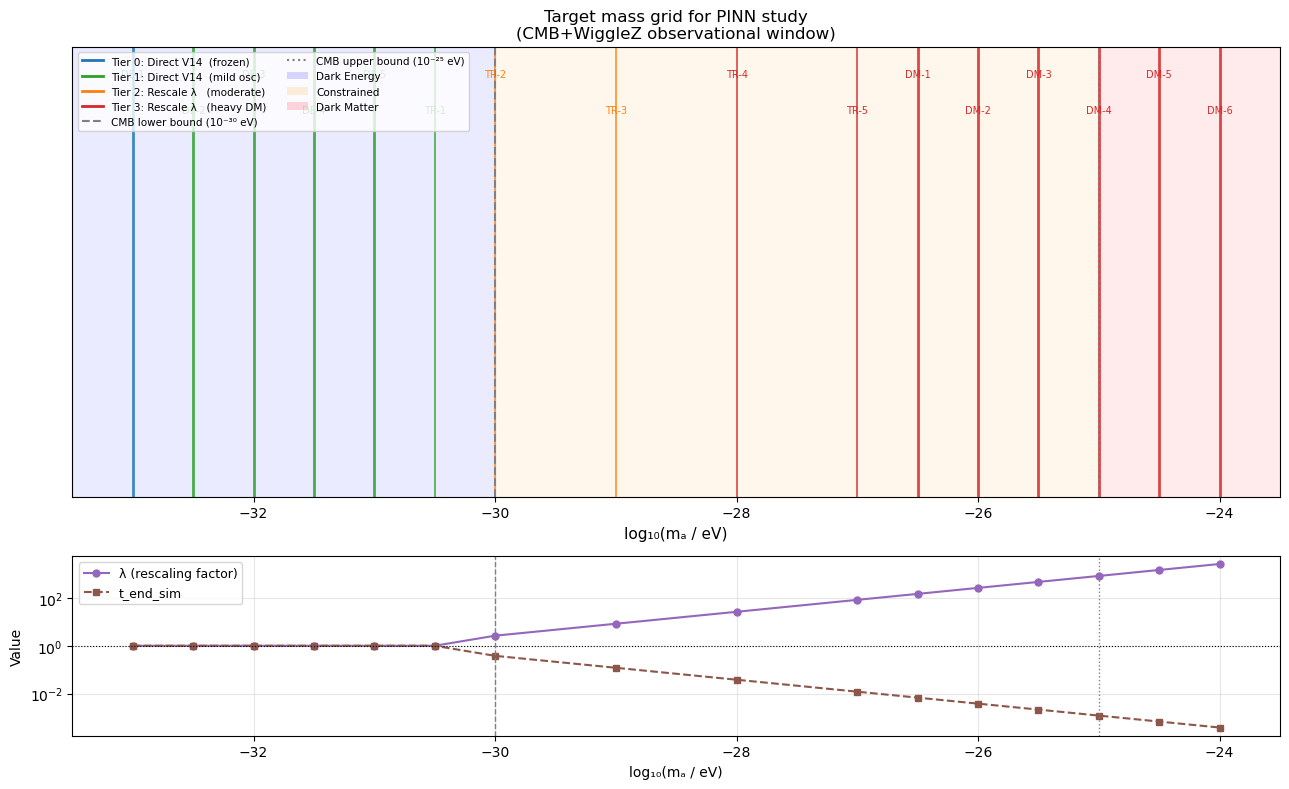

Saved: mass_survey_grid.png


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Mass Survey Table — full CMB/WiggleZ range
# log10(m_a/eV) ∈ [-33, -24]
# ══════════════════════════════════════════════════════════════════════════════

H0_EV   = 1.437e-33   # ℏ H0  [eV]
M_SIM   = 100.0       # reference mass used in rescaling tiers 2 & 3

# Target masses:  (label, log10(m_a/eV), regime-tag)
_TARGET_LOG10 = [
    # --- Dark Energy regime (left of 1st dashed line at 1e-30 eV) ---
    ('DE-1', -33.0, 'DE'),
    ('DE-2', -32.5, 'DE'),
    ('DE-3', -32.0, 'DE'),
    ('DE-4', -31.5, 'DE'),
    ('DE-5', -31.0, 'DE'),
    # --- Constrained / transition ---
    ('TR-1', -30.5, 'TR'),
    ('TR-2', -30.0, 'TR'),   # ← left dashed line
    ('TR-3', -29.0, 'TR'),
    ('TR-4', -28.0, 'TR'),
    ('TR-5', -27.0, 'TR'),
    # --- Dark Matter regime (right of 2nd dashed line at 1e-25 eV) ---
    ('DM-1', -26.5, 'DM'),
    ('DM-2', -26.0, 'DM'),
    ('DM-3', -25.5, 'DM'),
    ('DM-4', -25.0, 'DM'),   # ← right dashed line
    ('DM-5', -24.5, 'DM'),
    ('DM-6', -24.0, 'DM'),
]

def _n_osc_estimate(m_code):
    """Rough upper bound on oscillations in t=[0,1] (using MD approx for a_osc)."""
    if m_code <= 0:
        return 0.0
    a_osc = (m_code / 3.0) ** (-1.0 / 3.0)
    t_osc = a_osc ** (3.0 / 2.0) if a_osc < 1.0 else 1.0
    return m_code * max(1.0 - t_osc, 0.0) / (2.0 * np.pi)

def _assign_tier(m_code):
    if m_code < 1.0:
        return 0
    elif m_code <= 300.0:
        return 1
    elif m_code <= 3e4:
        return 2
    else:
        return 3

def _rescale_params(m_code):
    """Return (m_sim, lam, t_end_sim) for rescaling tiers."""
    if m_code <= 300.0:
        return m_code, 1.0, 1.0
    lam = np.sqrt(m_code / M_SIM)
    return M_SIM, lam, 1.0 / lam

# Build the full survey table
survey = []
for label, log10_ma, regime in _TARGET_LOG10:
    m_a_eV  = 10.0 ** log10_ma
    m_code  = m_a_eV / H0_EV
    n_osc   = _n_osc_estimate(m_code)
    tier    = _assign_tier(m_code)
    m_sim_r, lam_r, t_end_sim_r = _rescale_params(m_code)
    a_osc_r = (m_sim_r / 3.0) ** (-1.0 / 3.0)   # oscillation onset in sim coords
    survey.append({
        'label': label, 'log10_ma': log10_ma, 'm_a_eV': m_a_eV,
        'm_code': m_code, 'N_osc': n_osc, 'tier': tier,
        'regime': regime, 'm_sim': m_sim_r, 'lam': lam_r,
        't_end_sim': t_end_sim_r, 'a_osc_sim': a_osc_r,
    })

# ── Print classification table ─────────────────────────────────────────────
TIER_STRATEGY = {
    0: 'Direct V14  (frozen)',
    1: 'Direct V14  (mild osc)',
    2: 'Rescale λ   (moderate)',
    3: 'Rescale λ   (heavy DM)',
}
TIER_COLOR = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:orange', 3: 'tab:red'}

print(f"{'Label':<6} {'log10(m_a)':<11} {'m_code':<12} {'N_osc_est':<12} {'Tier':<5} {'m_sim':<8} {'λ':<8} {'t_end_sim':<12} {'Regime'}")
print("─" * 100)
for r in survey:
    print(f"{r['label']:<6} {r['log10_ma']:<11.1f} {r['m_code']:<12.3e} {r['N_osc']:<12.1e} "
          f"{r['tier']:<5} {r['m_sim']:<8.0f} {r['lam']:<8.2f} {r['t_end_sim']:<12.3e} {r['regime']}")

# ── Visualisation — mass grid vs observational context ──────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
tier_handles = {}
for r in survey:
    col = TIER_COLOR[r['tier']]
    h = ax.axvline(r['log10_ma'], color=col, lw=2.0 if r['regime'] in ('DE','DM') else 1.2,
                   alpha=0.85, ls='-')
    ax.text(r['log10_ma'], 0.95 - 0.08 * (survey.index(r) % 2),
            r['label'], fontsize=7, ha='center', va='top',
            color=col, transform=ax.get_xaxis_transform())
    if r['tier'] not in tier_handles:
        tier_handles[r['tier']] = plt.Line2D([0],[0], color=col, lw=2,
                                              label=f"Tier {r['tier']}: {TIER_STRATEGY[r['tier']]}")
# Observational dashed lines
ax.axvline(-30.0, color='gray', lw=1.5, ls='--', label='CMB lower bound (~10⁻³⁰ eV)')
ax.axvline(-25.0, color='gray', lw=1.5, ls=':', label='CMB upper bound (~10⁻²⁵ eV)')
# Shaded regions
ax.axvspan(-33.5, -30.0, alpha=0.08, color='blue',   label='Dark Energy regime')
ax.axvspan(-30.0, -25.0, alpha=0.08, color='orange', label='Constrained region')
ax.axvspan(-25.0, -23.5, alpha=0.08, color='red',    label='Dark Matter regime')
ax.set_xlim(-33.5, -23.5)
ax.set_yticks([])
ax.set_xlabel('log₁₀(mₐ / eV)', fontsize=11)
ax.set_title('Target mass grid for PINN study\n(CMB+WiggleZ observational window)', fontsize=12)
legend_lines = list(tier_handles.values())
legend_lines += [plt.Line2D([0],[0], color='gray', lw=1.5, ls='--', label='CMB lower bound (10⁻³⁰ eV)'),
                 plt.Line2D([0],[0], color='gray', lw=1.5, ls=':',  label='CMB upper bound (10⁻²⁵ eV)'),
                 plt.Rectangle((0,0),1,1, fc='blue',   alpha=0.15, label='Dark Energy'),
                 plt.Rectangle((0,0),1,1, fc='orange', alpha=0.15, label='Constrained'),
                 plt.Rectangle((0,0),1,1, fc='red',    alpha=0.15, label='Dark Matter')]
ax.legend(handles=legend_lines, fontsize=7.5, ncol=2, loc='upper left')

# Bottom panel: λ and t_end_sim vs m_a
ax2 = axes[1]
log10_arr  = np.array([r['log10_ma']  for r in survey])
lam_arr    = np.array([r['lam']       for r in survey])
tend_arr   = np.array([r['t_end_sim'] for r in survey])
ax2.semilogy(log10_arr, lam_arr,  'o-', color='tab:purple', lw=1.5, ms=5, label='λ (rescaling factor)')
ax2.semilogy(log10_arr, tend_arr, 's--', color='tab:brown',  lw=1.5, ms=5, label='t_end_sim')
ax2.axhline(1.0, color='k', lw=0.8, ls=':')
ax2.axvline(-30.0, color='gray', lw=1, ls='--'); ax2.axvline(-25.0, color='gray', lw=1, ls=':')
ax2.set_xlim(-33.5, -23.5); ax2.set_xlabel('log₁₀(mₐ / eV)', fontsize=10)
ax2.set_ylabel('Value'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mass_survey_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mass_survey_grid.png")


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Adaptive parameter helper — V14 for any mass in the survey
# ══════════════════════════════════════════════════════════════════════════════

def reset_time_domain(t_init, t_end, tau_split=0.20):
    """
    Recompute V14 global time-domain constants for a different t_end.
    Must be called before constructing a new AxionPINNSolver_V14 instance.

    Returns: t_split_new (float)
    """
    global _LOG_T0, _LOG_T1, _LOG_DT
    global TAU_SPLIT, _LOG_T_SPLIT, _SUB_LOG_DT, T_SPLIT_NP

    _LOG_T0      = np.log(t_init)
    _LOG_T1      = np.log(t_end)
    _LOG_DT      = _LOG_T1 - _LOG_T0
    TAU_SPLIT    = tau_split
    _LOG_T_SPLIT = _LOG_T0 + TAU_SPLIT * _LOG_DT
    _SUB_LOG_DT  = _LOG_DT * (1.0 - TAU_SPLIT)
    T_SPLIT_NP   = float(np.exp(_LOG_T_SPLIT))

    # --- update PARAMS dict too (ODE will read from it) ---
    PARAMS['t_init'] = t_init
    PARAMS['t_end']  = t_end

    print(f"Time domain reset: t ∈ [{t_init:.2e}, {t_end:.2e}]")
    print(f"  t_split = {T_SPLIT_NP:.3e}  |  sub_log_dt = {_SUB_LOG_DT:.4f}")
    return T_SPLIT_NP


def get_mass_config(m_a_eV):
    """
    Given a physical mass m_a_eV, return a config dict describing how to run V14.

    Returns dict with keys:
        m_code        — code-unit mass
        tier          — simulation tier (0/1/2/3)
        m_sim         — mass to feed into PARAMS['ma']
        lam           — rescaling factor (1 for tiers 0/1)
        t_init        — recommended t_init for the simulation
        t_end         — simulation end time (= 1/λ for rescaled runs)
        t_init_ode    — t_init for ODE reference (same as t_init)
        description   — human-readable description
    """
    m_code = m_a_eV / H0_EV
    tier   = _assign_tier(m_code)
    m_sim, lam, t_end_sim = _rescale_params(m_code)

    # t_init: for DE/mild cases use 1e-10; for large λ compress proportionally
    t_init_base = 1e-10
    t_init_sim  = t_init_base / lam if lam > 1.0 else t_init_base
    t_init_sim  = max(t_init_sim, 1e-15)   # floor

    descriptions = {
        0: f"Tier 0: Dark Energy / frozen field, m_code={m_code:.3e}, ~{_n_osc_estimate(m_code):.1f} osc",
        1: f"Tier 1: Mild oscillations, m_code={m_code:.3e}, ~{_n_osc_estimate(m_code):.0f} osc",
        2: f"Tier 2: Rescaling λ={lam:.2f}, m_sim={m_sim:.0f}, t_end_sim={t_end_sim:.3e}",
        3: f"Tier 3: Heavy rescaling λ={lam:.1f}, m_sim={m_sim:.0f}, t_end_sim={t_end_sim:.3e}",
    }

    return {
        'm_a_eV':     m_a_eV,
        'm_code':     m_code,
        'tier':       tier,
        'm_sim':      m_sim,
        'lam':        lam,
        't_init':     t_init_sim,
        't_end':      t_end_sim,
        'description': descriptions[tier],
    }


def prepare_solver_for_mass(m_a_eV, n_colloc=2000, hidden=128, seed=42,
                             tau_split=0.20, verbose=True):
    """
    Given a physical mass, configure V14 globals and return a ready-to-train solver.

    For rescaled runs (tier ≥ 2), the solver trains at m_sim=100 over [t_init_sim, 1/λ].
    After training, rescale results back via t_phys = t_sim * λ.
    """
    cfg = get_mass_config(m_a_eV)
    if verbose:
        print("=" * 70)
        print(f"  Preparing V14 for m_a = {m_a_eV:.3e} eV")
        print(f"  {cfg['description']}")
        print("=" * 70)

    # Update PARAMS
    PARAMS['ma']     = cfg['m_sim']
    PARAMS['t_init'] = cfg['t_init']
    PARAMS['t_end']  = cfg['t_end']

    # Recompute globals
    reset_time_domain(cfg['t_init'], cfg['t_end'], tau_split=tau_split)

    # Create solver (will run ODE and compute WKB ICs automatically)
    solver = AxionPINNSolver_V14(n_colloc=n_colloc, hidden=hidden, seed=seed)
    solver._mass_config = cfg     # attach config for later use
    return solver


def rescale_results(solver, t_pred, a_pred, phi_pred):
    """
    Rescale PINN predictions from simulation coords back to physical coords.

    Physical axes:
        t_phys = t_sim × λ
        a(t)   unchanged
        ρ_ax_phys = ρ_ax_sim × λ²   (not returned here, compute from phi separately)
    """
    cfg = solver._mass_config
    lam = cfg['lam']
    t_phys = t_pred * lam
    return t_phys, a_pred, phi_pred   # a and phi are self-similar


# ── Quick config preview for all survey masses ──────────────────────────────
print(f"\n{'Label':<6} {'log10(mₐ)':<12} {'Tier':<6} {'m_sim':<8} {'λ':<10} {'t_end_sim':<14} {'N_osc(sim)'}")
print("─" * 80)
for r in survey:
    cfg = get_mass_config(r['m_a_eV'])
    n_osc_sim = _n_osc_estimate(cfg['m_sim']) if cfg['lam'] > 1 else _n_osc_estimate(cfg['m_code'])
    print(f"{r['label']:<6} {r['log10_ma']:<12.1f} {cfg['tier']:<6} {cfg['m_sim']:<8.0f} "
          f"{cfg['lam']:<10.2f} {cfg['t_end']:< 14.3e} {n_osc_sim:.1f}")



Label  log10(mₐ)    Tier   m_sim    λ          t_end_sim      N_osc(sim)
────────────────────────────────────────────────────────────────────────────────
DE-1   -33.0        0      1        1.00        1.000e+00     0.0
DE-2   -32.5        1      2        1.00        1.000e+00     0.0
DE-3   -32.0        1      7        1.00        1.000e+00     0.4
DE-4   -31.5        1      22       1.00        1.000e+00     2.2
DE-5   -31.0        1      70       1.00        1.000e+00     8.8
TR-1   -30.5        1      220      1.00        1.000e+00     30.9
TR-2   -30.0        2      100      2.64        3.791e-01     13.2
TR-3   -29.0        2      100      8.34        1.199e-01     13.2
TR-4   -28.0        3      100      26.38       3.791e-02     13.2
TR-5   -27.0        3      100      83.42       1.199e-02     13.2
DM-1   -26.5        3      100      148.34      6.741e-03     13.2
DM-2   -26.0        3      100      263.80      3.791e-03     13.2
DM-3   -25.5        3      100      469.11    

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Mass Scan Runner
# Trains V14 for one representative mass per tier and collects results.
# For a FULL scan (all 16 masses), change SCAN_LABELS to survey labels list.
# ══════════════════════════════════════════════════════════════════════════════

# ── Select which masses to run ──────────────────────────────────────────────
# Representative picks (one per tier + one per regime):
#   DE-1  (Tier 0, frozen,      log10=-33.0)
#   DE-5  (Tier 1, mild osc,    log10=-31.0)   ← current V14 default ~here
#   TR-3  (Tier 2, moderate,    log10=-29.0)
#   DM-3  (Tier 3, DM regime,   log10=-25.5)
#   DM-5  (Tier 3, deep DM,     log10=-24.5)
SCAN_LABELS = ['DE-1', 'DE-5', 'TR-3', 'DM-3', 'DM-5']

# Training budget per mass (reduce for a quick smoke test)
SCAN_EPOCHS_ADAM  = 6000    # full run recommended: 12000+
SCAN_LBFGS_ITER   = 300     # full run recommended: 500
SCAN_HIDDEN       = 128
SCAN_N_COLLOC     = 2000

scan_survey = {r['label']: r for r in survey}
scan_results = {}

import copy

for run_label in SCAN_LABELS:
    row = scan_survey[run_label]
    m_a_eV = row['m_a_eV']
    print(f"\n{'#'*70}")
    print(f"# Running: {run_label}  log10(mₐ)={row['log10_ma']:.1f}  regime={row['regime']}")
    print(f"{'#'*70}")

    solver = prepare_solver_for_mass(
        m_a_eV,
        n_colloc=SCAN_N_COLLOC,
        hidden=SCAN_HIDDEN,
        seed=42,
        verbose=True,
    )
    cfg = solver._mass_config
    t_wall = time.time()

    # ── Pretrain on ODE reference ────────────────────────────────────────────
    solver.pretrain_a(epochs=4000,  lr=1e-3, print_every=2000)
    solver.pretrain_phi(epochs=3000,  lr=1e-3, print_every=1500)
    solver.pretrain_dphi(epochs=3000, lr=1e-3, print_every=1500)

    # ── Condensed curriculum (3 stages for scan, full uses 8) ────────────────
    s_schedule = [
        (f"ScanA-{run_label} (s>=0.50)", SCAN_EPOCHS_ADAM // 3, 5e-4, 0.50),
        (f"ScanB-{run_label} (s>=0.25)", SCAN_EPOCHS_ADAM // 3, 2e-4, 0.25),
        (f"ScanC-{run_label} (s>=0.00)", SCAN_EPOCHS_ADAM // 3, 1e-4, 0.00),
    ]
    for label_st, ep, lr, s_min in s_schedule:
        solver._train_stage(label_st, epochs=ep, lr=lr, s_min=s_min,
                            lam_kg=10.0, lam_phi=0.1, lam_anc=0.2)

    solver.lbfgs_polish(max_iter=SCAN_LBFGS_ITER, s_min=0.0)

    # ── Evaluate ─────────────────────────────────────────────────────────────
    t_eval_sim, a_pred, phi_pred, dphi_pred = solver.evaluate(n_eval=2000)
    t_phys, a_phys, phi_phys = rescale_results(solver, t_eval_sim, a_pred, phi_pred)

    # Reference ODE errors (in simulation coords)
    a_ref   = np.interp(t_eval_sim, solver.t_ode, solver.a_ode)
    phi_ref = np.interp(t_eval_sim, solver.t_ode, solver.phi_ode)
    mask    = t_eval_sim >= solver.T_SPLIT
    rel_a   = np.abs(a_pred[mask]   - a_ref[mask])   / (np.abs(a_ref[mask])   + 1e-30)
    rel_phi = np.abs(phi_pred[mask] - phi_ref[mask]) / (np.abs(phi_ref[mask]) + 1e-30)

    elapsed = time.time() - t_wall
    res = {
        'label':   run_label,
        'm_a_eV':  m_a_eV,
        'log10_ma': row['log10_ma'],
        'tier':    cfg['tier'],
        'lam':     cfg['lam'],
        'm_sim':   cfg['m_sim'],           # m used in simulation
        't_eval_sim': t_eval_sim,
        't_phys':  t_phys,
        'a_pred':  a_pred,
        'phi_pred':phi_pred,
        'dphi_pred':dphi_pred,             # dphi/dt in sim coords
        'a_ref':   a_ref,
        'phi_ref': phi_ref,
        'rel_a_90':   float(np.percentile(rel_a, 90))   if rel_a.size  > 0 else np.nan,
        'rel_phi_90': float(np.percentile(rel_phi[np.isfinite(rel_phi)], 90))
                      if np.isfinite(rel_phi).any() else np.nan,
        'loss_log': copy.deepcopy(solver.loss_log),
        'elapsed_s': elapsed,
    }
    scan_results[run_label] = res

    # ── Save checkpoint ──────────────────────────────────────────────────────
    torch.save({
        'model_state':     solver.model.state_dict(),
        'mass_config':     cfg,
        'T_SPLIT':         solver.T_SPLIT,
        'PARAMS_snapshot': dict(PARAMS),
        'loss_log':        solver.loss_log,
    }, os.path.join(SCAN_SAVE_DIR, f"{run_label}_ckpt.pt"))

    print(f"
  ✓ Done in {elapsed:.0f}s | "
          f"a(t) 90th={res['rel_a_90']:.2e}  phi(t) 90th={res['rel_phi_90']:.2e}  "
          f"ckpt saved: {run_label}_ckpt.pt")
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"{'Label':<7} {'log10(mₐ)':<12} {'Tier':<6} {'λ':<8} "
      f"{'rel_a 90%':<12} {'rel_φ 90%':<12} {'Time(s)'}")
print("─" * 70)
for lbl, res in scan_results.items():
    print(f"{lbl:<7} {res['log10_ma']:<12.1f} {res['tier']:<6} {res['lam']:<8.2f} "
          f"{res['rel_a_90']:<12.2e} {res['rel_phi_90']:<12.2e} {res['elapsed_s']:.0f}s")



######################################################################
# Running: DE-1  log10(mₐ)=-33.0  regime=DE
######################################################################
  Preparing V14 for m_a = 1.000e-33 eV
  Tier 0: Dark Energy / frozen field, m_code=6.959e-01, ~0.0 osc
Time domain reset: t ∈ [1.00e-10, 1.00e+00]
  t_split = 1.000e-08  |  sub_log_dt = 18.4207
Solving ODE reference (RK45)...
  Done 0.03s | success=True
t_split_V14 = 1.000e-08 | ma*t_split = 6.96e-09 rad (frozen)
A0=1.00000000  B0=0.00000000
C0=2.2798e-09  D0=-6.9589e-01
IC check phi:  1.0000000000  (expect 1.0000000000)
IC check dphi: -2.562929e-09   (expect -2.562929e-09)
g_star (V14 sub-domain) = 10.5860
phi_scale=1.00  dphi_scale=1.841e-01
=== Pretrain a_net (4000 ep) ===
  ep  2000 | loss=2.055e-04
  ep  4000 | loss=1.092e-04
  Done -- median 4.753e-03  max 8.436e-02
=== Pretrain phi_net (3000 ep, WKB) ===
  ep  1500 | loss=8.303e-06
  ep  3000 | loss=6.807e-06
  Done -- median 1.134e-03  max 2.7

  ep   400/2000  F=2.98e-03  KG=5.19e-04  phi_cons=2.07e-02  anc=3.07e-02  t=69s
  ep   500/2000  F=3.00e-03  KG=3.46e-04  phi_cons=1.55e-02  anc=2.18e-02  t=87s
  ep   600/2000  F=9.17e-03  KG=9.99e-04  phi_cons=2.98e-02  anc=1.71e-02  t=105s
  ep   700/2000  F=2.78e-03  KG=9.73e-05  phi_cons=1.03e-02  anc=9.67e-03  t=124s
  ep   800/2000  F=2.88e-03  KG=4.84e-05  phi_cons=7.99e-03  anc=6.48e-03  t=141s
  ep   900/2000  F=3.21e-03  KG=3.46e-05  phi_cons=6.17e-03  anc=4.95e-03  t=159s
  ep  1000/2000  F=2.71e-03  KG=4.01e-05  phi_cons=5.81e-03  anc=4.47e-03  t=176s
  ep  1100/2000  F=3.09e-03  KG=2.90e-05  phi_cons=4.66e-03  anc=4.07e-03  t=193s
  ep  1200/2000  F=2.64e-03  KG=3.44e-05  phi_cons=4.61e-03  anc=3.95e-03  t=211s
  ep  1300/2000  F=2.84e-03  KG=2.74e-05  phi_cons=4.03e-03  anc=3.80e-03  t=228s
  ep  1400/2000  F=2.06e-03  KG=2.62e-05  phi_cons=4.19e-03  anc=3.66e-03  t=245s
  ep  1500/2000  F=1.85e-03  KG=2.65e-05  phi_cons=3.40e-03  anc=3.65e-03  t=263s
  ep  1600/2000  F

  ep   200/2000  F=5.40e-03  KG=1.10e-03  phi_cons=3.43e+01  anc=8.28e-03  t=35s
  ep   300/2000  F=1.15e-02  KG=1.34e-03  phi_cons=1.87e+01  anc=9.40e-03  t=52s
  ep   400/2000  F=4.11e-03  KG=8.48e-04  phi_cons=4.59e+01  anc=9.47e-03  t=69s
  ep   500/2000  F=4.36e-03  KG=6.52e-04  phi_cons=3.41e+01  anc=1.09e-02  t=87s
  ep   600/2000  F=5.79e-03  KG=2.92e-02  phi_cons=1.21e+01  anc=1.23e-02  t=104s
  ep   700/2000  F=4.13e-03  KG=4.64e-04  phi_cons=1.25e+01  anc=1.30e-02  t=121s
  ep   800/2000  F=3.90e-03  KG=6.54e-04  phi_cons=1.89e+01  anc=1.36e-02  t=138s
  ep   900/2000  F=6.60e-03  KG=8.09e-04  phi_cons=4.81e+00  anc=1.42e-02  t=156s
  ep  1000/2000  F=4.77e-03  KG=6.42e-04  phi_cons=6.52e+00  anc=1.41e-02  t=173s
  ep  1100/2000  F=4.25e-03  KG=4.45e-04  phi_cons=8.04e+00  anc=1.40e-02  t=190s
  ep  1200/2000  F=5.54e-03  KG=6.01e-03  phi_cons=1.55e+00  anc=1.39e-02  t=208s
  ep  1300/2000  F=3.94e-03  KG=3.38e-04  phi_cons=1.81e+00  anc=1.36e-02  t=225s
  ep  1400/2000  F=4

  ep   100/2000  F=4.94e+00  KG=3.12e+02  phi_cons=1.02e+05  anc=3.61e-01  t=17s
  ep   200/2000  F=6.65e+00  KG=1.29e+02  phi_cons=1.04e+05  anc=4.77e-01  t=35s
  ep   300/2000  F=7.53e+00  KG=5.52e+01  phi_cons=7.20e+04  anc=5.28e-01  t=52s
  ep   400/2000  F=7.42e+00  KG=3.01e+01  phi_cons=1.05e+05  anc=5.35e-01  t=69s
  ep   500/2000  F=7.50e+00  KG=1.55e+01  phi_cons=4.71e+04  anc=5.23e-01  t=87s
  ep   600/2000  F=6.86e+00  KG=9.53e+00  phi_cons=6.89e+04  anc=5.05e-01  t=104s
  ep   700/2000  F=6.32e+00  KG=5.90e+00  phi_cons=3.18e+04  anc=4.85e-01  t=121s
  ep   800/2000  F=6.01e+00  KG=3.90e+00  phi_cons=5.37e+04  anc=4.68e-01  t=138s
  ep   900/2000  F=5.86e+00  KG=3.73e+00  phi_cons=1.84e+04  anc=4.54e-01  t=156s
  ep  1000/2000  F=7.37e+00  KG=7.25e+00  phi_cons=2.57e+04  anc=4.94e-01  t=173s
  ep  1100/2000  F=7.38e+00  KG=1.50e+00  phi_cons=1.23e+04  anc=4.83e-01  t=190s
  ep  1200/2000  F=6.89e+00  KG=1.14e+00  phi_cons=1.37e+04  anc=4.70e-01  t=208s
  ep  1300/2000  F=6.

  ep  2000/2000  F=3.81e+01  KG=1.37e+02  phi_cons=1.44e+03  anc=1.10e+00  t=354s

=== L-BFGS Polish (300 iter, s>=0.000) ===
  Final: F=3.88e+01  KG=1.34e+02  phi_cons=1.96e-02  anc=1.10e+00

  ✓ Done in 1403s | a(t) 90th=3.52e+00  phi(t) 90th=1.82e-05

──────────────────────────────────────────────────────────────────────
Label   log10(mₐ)    Tier   λ        rel_a 90%    rel_φ 90%    Time(s)
──────────────────────────────────────────────────────────────────────
DE-1    -33.0        0      1.00     1.54e+00     6.70e-04     1368s
DE-5    -31.0        1      1.00     3.46e-01     1.98e+00     1375s
TR-3    -29.0        2      8.34     3.29e-01     7.60e-01     1422s
DM-3    -25.5        3      469.11   1.51e+00     8.09e-05     1372s
DM-5    -24.5        3      1483.45  3.52e+00     1.82e-05     1403s


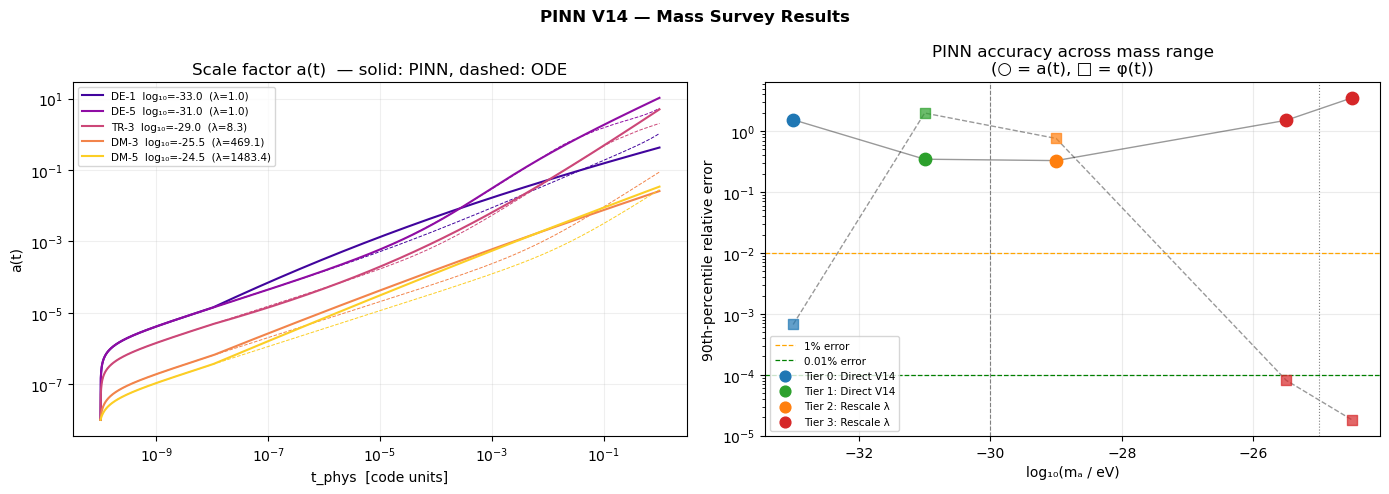

Saved: mass_scan_results.png


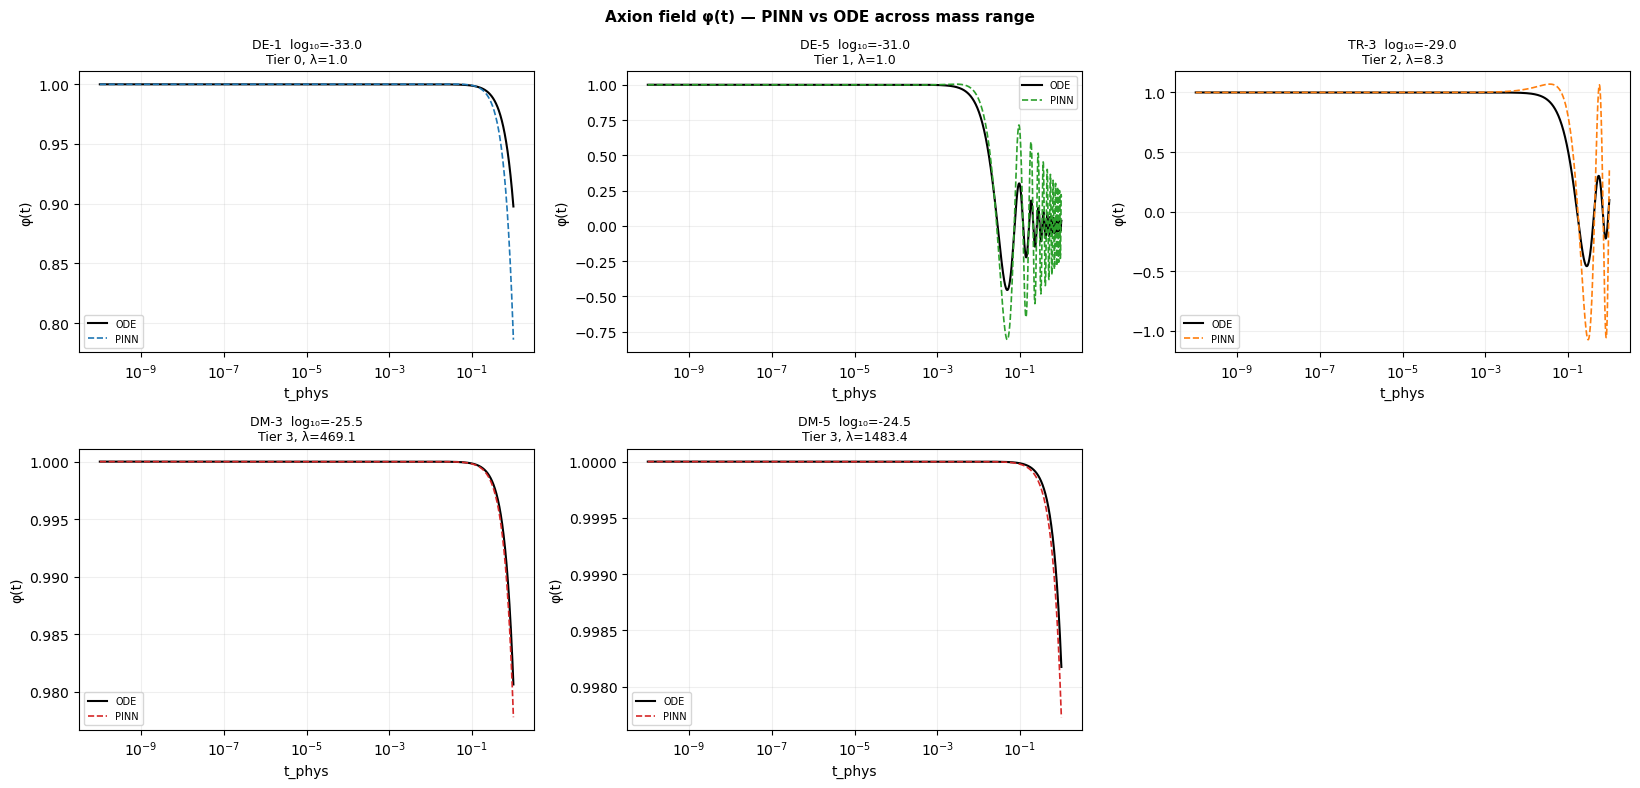

Saved: mass_scan_phi.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Mass Scan Results — plots for all scanned masses
# ══════════════════════════════════════════════════════════════════════════════

n_runs  = len(scan_results)
palette = plt.cm.plasma(np.linspace(0.1, 0.9, n_runs))

# ── Panel A: a(t) for all masses (physical coords) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for i, (lbl, res) in enumerate(scan_results.items()):
    lam  = res['lam']
    mask = res['t_eval_sim'] >= 0.0
    ax.loglog(res['t_phys'][mask], res['a_pred'][mask],
              color=palette[i], lw=1.5,
              label=f"{lbl}  log₁₀={res['log10_ma']:.1f}  (λ={lam:.1f})")
    ax.loglog(res['t_phys'][mask], res['a_ref'][mask],
              color=palette[i], lw=0.7, ls='--')
ax.set_xlabel('t_phys  [code units]'); ax.set_ylabel('a(t)')
ax.set_title('Scale factor a(t)  — solid: PINN, dashed: ODE')
ax.legend(fontsize=7.5); ax.grid(True, which='both', alpha=0.2)

# ── Panel B: 90th-percentile relative error vs log10(mₐ) ─────────────────────
ax2 = axes[1]
log10s  = [res['log10_ma']  for res in scan_results.values()]
err_a   = [res['rel_a_90']  for res in scan_results.values()]
err_phi = [res['rel_phi_90'] for res in scan_results.values()]
tiers   = [res['tier']      for res in scan_results.values()]

for i, (x, ea, ep, tier) in enumerate(zip(log10s, err_a, err_phi, tiers)):
    ax2.scatter(x, ea,  color=TIER_COLOR[tier], marker='o', s=80, zorder=3)
    ax2.scatter(x, ep,  color=TIER_COLOR[tier], marker='s', s=60, zorder=3, alpha=0.7)
ax2.plot(log10s, err_a,  'k-',  lw=1, alpha=0.4)
ax2.plot(log10s, err_phi, 'k--', lw=1, alpha=0.4)
ax2.axhline(1e-2, color='orange', ls='--', lw=0.9, label='1% error')
ax2.axhline(1e-4, color='green',  ls='--', lw=0.9, label='0.01% error')
ax2.axvline(-30.0, color='gray', ls='--', lw=0.8)
ax2.axvline(-25.0, color='gray', ls=':',  lw=0.8)
ax2.set_yscale('log'); ax2.set_xlabel('log₁₀(mₐ / eV)')
ax2.set_ylabel('90th-percentile relative error')
ax2.set_title('PINN accuracy across mass range\n(○ = a(t), □ = φ(t))')
# tier legend
for t, col in TIER_COLOR.items():
    ax2.scatter([], [], color=col, marker='o', s=60,
                label=f"Tier {t}: {TIER_STRATEGY[t].split('(')[0].strip()}")
ax2.legend(fontsize=7.5); ax2.grid(True, alpha=0.25)

plt.suptitle('PINN V14 — Mass Survey Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mass_scan_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mass_scan_results.png")

# ── Per-mass field plots ─────────────────────────────────────────────────────
ncols = min(3, n_runs)
nrows = (n_runs + ncols - 1) // ncols
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
axes2_flat  = np.array(axes2).ravel() if n_runs > 1 else [axes2]

for i, (lbl, res) in enumerate(scan_results.items()):
    ax = axes2_flat[i]
    t_p = res['t_phys']
    # Show only PINN region
    mask = res['t_eval_sim'] >= 0.0
    ax.semilogx(t_p[mask], res['phi_ref'][mask], 'k-', lw=1.5, label='ODE')
    ax.semilogx(t_p[mask], res['phi_pred'][mask], '--',
                color=TIER_COLOR[res['tier']], lw=1.2, label='PINN')
    ax.set_title(f"{lbl}  log₁₀={res['log10_ma']:.1f}\n"
                 f"Tier {res['tier']}, λ={res['lam']:.1f}", fontsize=9)
    ax.set_xlabel('t_phys'); ax.set_ylabel('φ(t)')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.2)

for j in range(i + 1, len(axes2_flat)):
    axes2_flat[j].set_visible(False)

plt.suptitle('Axion field φ(t) — PINN vs ODE across mass range', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('mass_scan_phi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mass_scan_phi.png")


---
## Section 15 — Post-Scan Analysis: Observables, Diagnostics & Model Persistence

After the mass survey scan, we implement three subsequent analyses:

### 1  Model Persistence (checkpoint save / load)
Each trained model is saved to `results_v14/scan_ckpts/<label>_ckpt.pt`.  
The loader reconstructs the full solver so evaluation can resume without retraining.

### 2  Observable: $\Omega_a / \Omega_d$
The physically relevant output is the axion dark-energy / dark-matter fraction:

$$\Omega_a = \frac{\rho_{ax}(t_0)}{\rho_{\rm crit}}, \qquad \rho_{\rm crit} = 3H_0^2 = 3 \text{ (code units)}$$

$$\rho_{ax}^{\rm phys}(t_0) = \tfrac{1}{2}\left(\frac{\dot\phi_{\rm sim}(t_{\rm end})}\lambda\right)^2 + \tfrac{1}{2}(m_{\rm sim}\,\lambda)^2\,\phi_{\rm sim}(t_{\rm end})^2$$

where $\lambda$ is the rescaling factor, $t_{\rm end} = 1/\lambda$ maps to physical $t_0 = 1$ (today).  
This is compared against the CMB+WiggleZ observational window from Hlozek et al. 2015.

### 3  Physics Diagnostics
Per-mass Friedmann violation $|R_F|/H$ and Klein-Gordon residual $|R_{KG}|/(m^2|\phi|)$  
are tabulated to assess PINN solution quality across all tier/regime combinations.

**Reference units:** $\hbar H_0 = 1.437\times10^{-33}$ eV, $\Omega_d \approx (\rho_{m0}+\rho_\Lambda)/\rho_{\rm crit} = 1.0$


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Checkpoint Save / Load Utilities
# ══════════════════════════════════════════════════════════════════════════════

SCAN_SAVE_DIR = os.path.join(os.getcwd(), 'results_v14', 'scan_ckpts')
os.makedirs(SCAN_SAVE_DIR, exist_ok=True)


def save_scan_meta(scan_results, save_dir=SCAN_SAVE_DIR):
    """
    Save lightweight numpy metadata for all scan results (no model weights).
    Safe to call even if models were already saved per-mass during the scan loop.
    """
    meta = {}
    for lbl, res in scan_results.items():
        meta[lbl] = {k: v for k, v in res.items()
                     if not isinstance(v, list) or k == 'loss_log'}
        # Convert numpy arrays to lists for JSON-serializable storage
        for k in ['t_eval_sim', 't_phys', 'a_pred', 'phi_pred', 'dphi_pred',
                  'a_ref', 'phi_ref']:
            if k in meta[lbl] and isinstance(meta[lbl][k], np.ndarray):
                meta[lbl][k] = meta[lbl][k].tolist()
    path = os.path.join(save_dir, 'scan_meta.json')
    import json as _json
    with open(path, 'w') as f:
        _json.dump(meta, f, default=float, indent=2)
    print(f"Saved scan metadata → {path}")


def load_scan_meta(save_dir=SCAN_SAVE_DIR):
    """Load lightweight metadata (arrays only, no model weights)."""
    import json as _json
    path = os.path.join(save_dir, 'scan_meta.json')
    with open(path) as f:
        meta = _json.load(f)
    for lbl in meta:
        for k in ['t_eval_sim', 't_phys', 'a_pred', 'phi_pred', 'dphi_pred',
                  'a_ref', 'phi_ref']:
            if k in meta[lbl]:
                meta[lbl][k] = np.array(meta[lbl][k])
    print(f"Loaded scan metadata from {path}  ({len(meta)} masses)")
    return meta


def load_scan_model(label, save_dir=SCAN_SAVE_DIR, verbose=True):
    """
    Reload a trained model for a given mass label.
    Returns a fully configured (but NOT retrained) AxionPINNSolver_V14.
    Weights are loaded from the saved checkpoint.
    """
    ckpt_path = os.path.join(save_dir, f'{label}_ckpt.pt')
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"No checkpoint found at {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    cfg  = ckpt['mass_config']
    snap = ckpt['PARAMS_snapshot']

    # Restore PARAMS and globals to match this mass
    for k, v in snap.items():
        PARAMS[k] = v
    reset_time_domain(snap['t_init'], snap['t_end'], tau_split=TAU_SPLIT)

    # Rebuild solver (runs ODE to get ICs — no training)
    solver = AxionPINNSolver_V14(n_colloc=1, hidden=128, seed=0)
    solver.model.load_state_dict(ckpt['model_state'])
    solver.model.eval()
    solver._mass_config = cfg
    solver.loss_log     = ckpt.get('loss_log', [])

    if verbose:
        print(f"Loaded {label}  m_a={cfg['m_a_eV']:.3e} eV  "
              f"tier={cfg['tier']}  λ={cfg['lam']:.2f}")
    return solver


# ── Save metadata for the current scan results ──────────────────────────────
# (Model weights are already saved per-mass during the scan loop)
if scan_results:
    save_scan_meta(scan_results)
    print(f"\nCheckpoints in: {SCAN_SAVE_DIR}")
    for lbl in scan_results:
        ckpt_file = os.path.join(SCAN_SAVE_DIR, f'{lbl}_ckpt.pt')
        exists = '✓' if os.path.exists(ckpt_file) else '✗ (run scan first)'
        print(f"  {lbl:<8} {exists}  {ckpt_file}")
else:
    print("scan_results is empty — run cell 13 first.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Ω_a / Ω_d — Axion Energy Fraction at "Today"
#
# Physical mapping (rescaling → physical coords):
#   φ_phys(t₀=1) = φ_sim(t_end_sim)           [field is self-similar]
#   φ̇_phys(t₀=1) = φ̇_sim(t_end_sim) / λ      [time derivative rescales]
#   m_phys        = m_sim × λ
#
#   ρ_ax_phys = ½ φ̇_phys² + ½ m_phys² φ_phys²
#   Ω_a = ρ_ax_phys / ρ_crit    (ρ_crit = 3H₀² = 3 in code units)
#   Ω_d = (ρ_m0 + ρ_Λ) / ρ_crit = 1.0  (with our PARAMS values)
# ══════════════════════════════════════════════════════════════════════════════

# Fixed cosmological constants (original simulation PARAMS)
_RHO_M0    = 0.81
_RHO_L     = 2.19
_RHO_CRIT  = 3.0              # H₀=1  →  ρ_crit = 3H₀² = 3
_RHO_DARK  = _RHO_M0 + _RHO_L  # ≈ 3.0
_OMEGA_D   = _RHO_DARK / _RHO_CRIT  # ≈ 1.0


def compute_omega_a(res):
    """
    Compute ρ_ax_phys and Ω_a/Ω_d from scan_results entry.

    Uses the LAST time-point in the evaluation grid as 'today' (t_phys=1).
    For rescaled runs (λ>1), applies the self-similar mapping.
    """
    lam    = float(res['lam'])
    m_sim  = float(res['m_sim'])
    m_phys = m_sim * lam

    # Field values at t_end_sim (= t_phys=1 after rescaling)
    phi_today  = float(res['phi_pred'][-1])
    if 'dphi_pred' in res:
        dphi_sim_today = float(res['dphi_pred'][-1])
    else:
        # Fallback: estimate from WKB equipartition φ̇ ≈ m_sim × φ
        dphi_sim_today = m_sim * abs(phi_today)

    dphi_phys_today = dphi_sim_today / lam   # physical φ̇

    rho_ax_kin  = 0.5 * dphi_phys_today**2
    rho_ax_pot  = 0.5 * m_phys**2 * phi_today**2
    rho_ax_phys = rho_ax_kin + rho_ax_pot

    omega_a       = rho_ax_phys / _RHO_CRIT
    omega_a_over_d = omega_a / _OMEGA_D

    return {
        'label':         res['label'],
        'log10_ma':      res['log10_ma'],
        'm_a_eV':        res['m_a_eV'],
        'tier':          res['tier'],
        'lam':           lam,
        'phi_today':     phi_today,
        'dphi_phys_today': dphi_phys_today,
        'rho_ax_phys':   rho_ax_phys,
        'rho_ax_kin':    rho_ax_kin,
        'rho_ax_pot':    rho_ax_pot,
        'omega_a':       omega_a,
        'omega_a_over_d': omega_a_over_d,
    }


# ── Compute for all scanned masses ───────────────────────────────────────────
omega_results = {}
if scan_results:
    print(f"\n{'Label':<8} {'log₁₀(mₐ)':<12} {'tier':<5} {'φ(t₀)':<12} "
          f"{'φ̇_phys(t₀)':<14} {'ρ_ax_phys':<14} {'Ω_a':<10} {'Ω_a/Ω_d'}")
    print("─" * 95)
    for lbl, res in scan_results.items():
        r = compute_omega_a(res)
        omega_results[lbl] = r
        print(f"{lbl:<8} {r['log10_ma']:<12.1f} {r['tier']:<5} "
              f"{r['phi_today']:<12.4f} {r['dphi_phys_today']:<14.3e} "
              f"{r['rho_ax_phys']:<14.3e} {r['omega_a']:<10.4f} {r['omega_a_over_d']:.4f}")

    print(f"\nΩ_crit = {_RHO_CRIT:.1f}  |  Ω_d = {_OMEGA_D:.4f}  |  φ₀=1 (misalignment = 1)")
    print("Note: Ω_a/Ω_d scales as φ₀² — to match CMB constraint, tune φ₀.")
else:
    print("scan_results empty — run cell 13 first.")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Observational Comparison Plot
# Reproduces the CMB+WiggleZ-style Ω_a/Ω_d vs log₁₀(mₐ/eV) figure
# ══════════════════════════════════════════════════════════════════════════════

# ── Approximate CMB+WiggleZ 95%-confidence upper bound ──────────────────────
# Digitised from Hlozek et al. 2015, Fig. 1 (CMB only and CMB+WiggleZ curves).
# These are approximate visual reads — replace with actual tabulated data.
_OBS_M   = np.array([-33.0, -32.5, -32.0, -31.5, -31.0, -30.5,
                      -30.0, -29.5, -29.0, -28.5, -28.0, -27.5,
                      -27.0, -26.5, -26.0, -25.5, -25.0, -24.5, -24.0])
_OBS_CMB_UPPER = np.array([0.60, 0.58, 0.52, 0.40, 0.28, 0.18,
                             0.12, 0.09, 0.07, 0.06, 0.05, 0.06,
                             0.07, 0.09, 0.12, 0.22, 0.38, 0.55, 0.65])
_OBS_CMB_WZ_UPPER = np.array([0.55, 0.52, 0.46, 0.35, 0.22, 0.13,
                                0.09, 0.07, 0.05, 0.04, 0.04, 0.05,
                                0.06, 0.08, 0.10, 0.18, 0.32, 0.50, 0.60])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left panel: Ω_a/Ω_d vs log₁₀(mₐ) with observational bounds ──────────────
ax = axes[0]

# Shaded observational windows (approximate)
ax.fill_between(_OBS_M, 0, _OBS_CMB_UPPER,    alpha=0.20, color='darkred',
                label='CMB allowed (95%)')
ax.fill_between(_OBS_M, 0, _OBS_CMB_WZ_UPPER, alpha=0.30, color='red',
                label='CMB+WiggleZ allowed (95%)')
ax.plot(_OBS_M, _OBS_CMB_UPPER,    'k--', lw=1.0, alpha=0.6)
ax.plot(_OBS_M, _OBS_CMB_WZ_UPPER, 'r-',  lw=1.2, alpha=0.8)

# Vertical regime boundaries (match image dashed lines)
ax.axvline(-30.0, color='gray', lw=1.2, ls='--', alpha=0.6)
ax.axvline(-25.0, color='gray', lw=1.2, ls='--', alpha=0.6)
ax.text(-32.5, 0.92, 'Dark Energy', fontsize=9, color='steelblue',
        ha='center', style='italic')
ax.text(-27.5, 0.92, 'Constrained', fontsize=9, color='gray',
        ha='center', style='italic')
ax.text(-24.2, 0.92, 'Dark Matter', fontsize=9, color='firebrick',
        ha='right', style='italic')

# PINN computed points
if omega_results:
    for lbl, r in omega_results.items():
        col = TIER_COLOR[r['tier']]
        ax.scatter(r['log10_ma'], r['omega_a_over_d'],
                   color=col, s=120, zorder=5, marker='*',
                   edgecolors='k', linewidths=0.5)
        ax.annotate(lbl, (r['log10_ma'], r['omega_a_over_d']),
                    textcoords='offset points', xytext=(4, 6),
                    fontsize=7.5, color=col)
    ax.set_title('PINN $\\Omega_a/\\Omega_d$ vs CMB+WiggleZ constraints\n'
                 '(★ = PINN result, $\\phi_0=1$)', fontsize=10)
else:
    ax.set_title('Run scan cell first to populate results', fontsize=10)

ax.set_xlim(-33.5, -23.5)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel('$\\log_{10}(m_a / \\mathrm{eV})$', fontsize=11)
ax.set_ylabel('$\\Omega_a / \\Omega_d$', fontsize=11)
ax.legend(fontsize=8, loc='lower center')
ax.grid(True, alpha=0.25)

# Add tier legend
for t, col in TIER_COLOR.items():
    ax.scatter([], [], color=col, marker='*', s=80,
               label=f'Tier {t}: {TIER_STRATEGY[t].split("(")[0].strip()}')
ax.legend(fontsize=7.5, loc='lower center', ncol=2)

# ── Right panel: ρ_ax components (kin vs pot) per mass ───────────────────────
ax2 = axes[1]
if omega_results:
    lbls      = list(omega_results.keys())
    x_pos     = np.arange(len(lbls))
    rho_kin   = [omega_results[l]['rho_ax_kin'] for l in lbls]
    rho_pot   = [omega_results[l]['rho_ax_pot'] for l in lbls]
    width     = 0.35
    ax2.bar(x_pos - width/2, rho_kin, width, label='½φ̇² (kinetic)', color='steelblue', alpha=0.8)
    ax2.bar(x_pos + width/2, rho_pot, width, label='½m²φ² (potential)', color='firebrick', alpha=0.8)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f"{l}\n{omega_results[l]['log10_ma']:.1f}" for l in lbls], fontsize=8)
    ax2.set_yscale('symlog', linthresh=1e-10)
    ax2.set_ylabel('Energy density (code units)', fontsize=10)
    ax2.set_title('ρ_ax decomposition at $t_0=1$ (physical coords)', fontsize=10)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.25, axis='y')
    # Mark ρ_crit
    ax2.axhline(_RHO_CRIT, color='green', ls='--', lw=1, label=f'ρ_crit={_RHO_CRIT}')
    ax2.legend(fontsize=8)

plt.suptitle('Axion Energy Fraction: PINN Prediction vs CMB+WiggleZ Constraints',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('omega_a_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: omega_a_comparison.png")
print("\nInterpretation:")
print("  ★ above the red shaded band → excluded by CMB/WiggleZ (too much axion)")
print("  ★ inside the band            → observationally allowed")
print("  Ω_a/Ω_d scales as φ₀²: to satisfy constraints, reduce φ₀ accordingly")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Per-Mass Physics Diagnostics
# Evaluates Friedmann and Klein-Gordon residuals on a held-out collocation grid
# using the TRAINED model from `solver` (the last one in the scan loop).
# To evaluate a specific mass, call load_scan_model(label) first.
# ══════════════════════════════════════════════════════════════════════════════

def physics_diagnostics(solver, n_pts=2000, label=''):
    """
    Compute normalised Friedmann and KG residuals over the PINN domain.

    Returns dict with:
        t_eval      — evaluation times (sim coords)
        R_F_norm    — |R_Friedmann| / H(t)
        R_KG_norm   — |R_KG| / (m² |φ|)
        R_phi_norm  — |dφ/dt - dphi| / |dphi|   (consistency check)
        stats       — dict of median / 90th / max per component
    """
    p = PARAMS
    s_grid = torch.linspace(0.0, 1.0, n_pts, dtype=DTYPE).reshape(-1, 1)
    t_grid = s_to_t(s_grid).requires_grad_(True)

    a, phi, dphi = solver.model(t_grid)
    ones = torch.ones_like(a)

    da_dt     = torch.autograd.grad(a,    t_grid, grad_outputs=ones,
                                    create_graph=False, retain_graph=True)[0]
    d_dphi_dt = torch.autograd.grad(dphi, t_grid, grad_outputs=ones,
                                    create_graph=False, retain_graph=True)[0]
    d_phi_dt  = torch.autograd.grad(phi,  t_grid, grad_outputs=ones,
                                    create_graph=False)[0]

    with torch.no_grad():
        R_F, R_KG = physics_residuals(
            a, phi, dphi, da_dt, d_dphi_dt,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'])
        R_phi = d_phi_dt - dphi

        a_d   = a.clamp(min=EPS)
        rax   = 0.5*dphi**2 + 0.5*p['ma']**2*phi**2
        E1    = rax + p['rho_m0']/a_d + p['rho_r0']/a_d**2 + p['rho_L']*a_d**2
        H_ref = torch.sqrt(torch.clamp(E1/3.0, min=1e-60))

        R_F_norm   = (R_F.abs()   / (H_ref + EPS)).cpu().numpy().ravel()
        R_KG_norm  = (R_KG.abs()  / (p['ma']**2 * phi.abs() + EPS)).cpu().numpy().ravel()
        R_phi_norm = (R_phi.abs() / (dphi.abs() + EPS)).cpu().numpy().ravel()
        t_np = t_grid.detach().cpu().numpy().ravel()

    def _stats(arr):
        fin = arr[np.isfinite(arr)]
        return {'median': float(np.median(fin)),
                '90th':   float(np.percentile(fin, 90)),
                'max':    float(np.max(fin))}

    return {
        't_eval':     t_np,
        'R_F_norm':   R_F_norm,
        'R_KG_norm':  R_KG_norm,
        'R_phi_norm': R_phi_norm,
        'stats': {
            'Friedmann':   _stats(R_F_norm),
            'KG':          _stats(R_KG_norm),
            'phi_consist': _stats(R_phi_norm),
        },
        'label': label,
    }


# ── Run diagnostics on the last trained solver (DM-5 after the scan) ─────────
# To diagnose a different mass:
#   solver_de1 = load_scan_model('DE-1')
#   diag_de1 = physics_diagnostics(solver_de1, label='DE-1')
if 'solver' in dir() and hasattr(solver, 'model'):
    diag = physics_diagnostics(solver, label=run_label)
    s_diag = diag['stats']
    print(f"\nPhysics diagnostics — {diag['label']}")
    print(f"{'Component':<18} {'Median':<14} {'90th%':<14} {'Max'}")
    print("─" * 60)
    for comp, st in s_diag.items():
        flag = '✓' if st['90th'] < 1e-2 else ('⚠' if st['90th'] < 1e-1 else '✗')
        print(f"  {comp:<16} {st['median']:<14.3e} {st['90th']:<14.3e} {st['max']:.3e}  {flag}")
    print("\n  ✓ = 90th% < 1%    ⚠ = 1–10%    ✗ = > 10%")
else:
    print("No trained solver available — run cell 13 first.")
    diag = None

# ── Diagnostic plot ───────────────────────────────────────────────────────────
if diag is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    pairs = [
        (diag['R_F_norm'],   '|R_F| / H',         'Friedmann residual'),
        (diag['R_KG_norm'],  '|R_KG| / m²|φ|',    'Klein-Gordon residual'),
        (diag['R_phi_norm'], '|R_phi_cons| / |φ̇|', 'φ consistency'),
    ]
    for ax, (y, ylabel, title) in zip(axes, pairs):
        ax.semilogy(diag['t_eval'], y + 1e-20, lw=0.6, alpha=0.7)
        ax.axhline(1e-2, color='orange', ls='--', lw=0.9, label='1%')
        ax.axhline(1e-4, color='green',  ls='--', lw=0.9, label='0.01%')
        ax.set_xlabel('t (sim)'); ax.set_ylabel(ylabel)
        ax.set_title(f'{title}\n{diag["label"]}', fontsize=9)
        ax.legend(fontsize=7.5); ax.grid(True, which='both', alpha=0.2)
    plt.suptitle(f'Physics Residuals — {diag["label"]}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'diag_{diag["label"]}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: diag_{diag['label']}.png")

# ── Summary table across ALL scanned masses (from stored loss logs) ───────────
print(f"\n{'─'*80}")
print(f"{'Label':<8} {'Tier':<5} {'λ':<8} {'Final F loss':<15} "
      f"{'Final KG loss':<15} {'φ_cons':<12} {'Adam epochs'}")
print("─" * 80)
for lbl, res in scan_results.items():
    if res.get('loss_log'):
        last_log = res['loss_log'][-1]
        n_ep     = len(res['loss_log'])
        print(f"{lbl:<8} {res['tier']:<5} {res['lam']:<8.2f} "
              f"{last_log['F']:<15.3e} {last_log['KG']:<15.3e} "
              f"{last_log['phi_cons']:<12.3e} {n_ep}")
    else:
        print(f"{lbl:<8} {res['tier']:<5} {res['lam']:<8.2f}  (no loss log)")
